# TrustXAI-Derm: When Should Clinicians NOT Trust an AI Explanation?
## A Trust-Aware Framework for Dermoscopic Skin Cancer Diagnosis
### FIXED EDITION — checkpoint/resume, time-budget guards, novelty additions

---

## WARNING: READ FIRST — Kaggle Session Strategy (fixes "session end / stop / spec / time" issues)

**1. Use "Save & Run All (Commit)", not the interactive editor.**
Interactive Kaggle sessions die when your browser tab sleeps or your laptop locks — that's the #1 cause of
silent "session end" loss. Commit runs execute in the background on Kaggle's servers and have their own
(longer) GPU time budget, independent of your browser.

**2. Every expensive cell in this notebook is now resumable.**
Cells 7, 8, 10, 10b, 12, 13, 14, 15, 16, 17 all check a checkpoint file first. If the kernel dies, times out,
or you manually stop it, re-running the notebook (even a fresh commit) picks up from the last saved batch
instead of starting over.

**3. Checkpoints must survive between Kaggle sessions.**
`/kaggle/working` is wiped between *separate* commits unless you do one of:
- Output the previous commit's `/kaggle/working` as a Kaggle Dataset, then attach that dataset as input to
  the next run (`CFG['ckpt_input_dir']` below points at it). **This is the recommended pattern for a
  multi-session run.**
- Or just keep re-running the *same* interactive session / commit, where `/kaggle/working` persists for the
  life of that session.

**4. A global time budget stops heavy loops before Kaggle kills the kernel.**
`CFG['time_budget_seconds']` is checked inside every resumable loop. When you're within `margin` seconds of
the budget, the loop saves what it has and exits cleanly — instead of getting killed mid-write and losing the
whole batch. Set this a little under your actual GPU quota (e.g. 8h if you have a 9h T4 budget).

**5. GPU spec issues (OOM, DataParallel mismatches).**
`CFG['batch_size']` auto-halves on a caught CUDA OOM in the training loop (Cell 7/8) instead of crashing the
whole run. SHAP (Cell 12) is switched from `DeepExplainer` to `GradientExplainer`, which is faster and far
less memory-hungry for CNNs — this was the main blocker to running XDI on the *full* test set instead of a
200-image sample.

---

## CELL 1 — Install Dependencies (FIXED: shap, albumentations, scikit-image were used but never installed)


In [1]:
# ============================================================
# CELL 1 — Install all required packages
# Runtime: ~60-90 seconds
# FIX: original notebook imported shap, albumentations, and skimage
# in later cells without ever pip-installing them. On a Kaggle base
# image these are sometimes preinstalled and sometimes not -- pinning
# them here removes a silent "works today, ImportError tomorrow" risk.
# ============================================================
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

# FIX (third revision -- see history below): earlier attempts got this
# wrong in two different ways.
#   v1: installed each package one-at-a-time, letting pip resolve deps
#       freely. On a local test env this silently upgraded numpy past
#       the ceiling shap's numba dependency tolerates.
#   v2: "fixed" v1 by re-pinning numpy back down as a separate step
#       afterward. This broke Kaggle for real: Kaggle's own pandas is
#       pre-compiled against Kaggle's shipped numpy, so downgrading numpy
#       via pip after pandas is already on disk breaks pandas' compiled
#       C-extension ABI ("numpy.dtype size changed... Expected 96 from
#       C header, got 88 from PyObject" the moment `import pandas` ran).
#   v2b: tried --no-deps for every package to avoid touching numpy at
#       all. This went too far the other way: albumentations==1.4.15
#       needs a SPECIFIC compatible version of its own albucore
#       dependency, and --no-deps prevented that from being resolved,
#       so `import albumentations` failed with
#       "ImportError: cannot import name 'preserve_channel_dim' from
#       albucore.utils" against whatever albucore Kaggle happened to
#       already have.
#
# Correct fix: let pip's dependency resolver see every package's real
# constraints TOGETHER in a single call (not one separate subprocess per
# package, which is what caused v1's silent numpy drift in the first
# place), while EXPLICITLY pinning numpy to whatever Kaggle already has
# installed. This lets pip find a consistent set of versions for
# timm/grad-cam/torchmetrics/shap/albumentations/scikit-image (including
# a correct, compatible albucore for albumentations) that all agree with
# the numpy Kaggle's own pandas/scipy were built against, instead of
# either letting numpy drift (v1) or blocking legitimate sub-dependency
# resolution outright (v2b).
import numpy as _np_probe
_pinned_numpy = f'numpy=={_np_probe.__version__}'
print(f'Pinning numpy to the version Kaggle already has installed: {_pinned_numpy}')

packages = [
    'timm==1.0.3', # Model zoo: ConvNeXt-Tiny
    'grad-cam==1.5.5', # GradCAMPlusPlus hook library
    'torchmetrics==1.4.2', # Accuracy/F1/AUC/ECE
    'shap==0.46.0', # FIX: was imported (Cell 2/12/14) but never installed
    'albumentations>=1.4.24', # FIX (v4): exact pin 1.4.24 hard-requires albucore==0.0.23, which is missing preserve_channel_dim -> ImportError on import albumentations. Unpinning the upper bound lets pip resolve a self-consistent, currently-shipping albumentations/albucore pair instead of that broken snapshot.
    'scikit-image==0.24.0', # FIX: was imported (Cell 17/19) but never installed
    _pinned_numpy, # keep numpy fixed at Kaggle's own version through the joint resolve
]
try:
    pip_install(*packages)
except subprocess.CalledProcessError as e:
    print(f'WARNING: joint install failed: {e}. Falling back to installing each package '
          f'separately (numpy pin included in every call to keep it fixed).')
    for pkg in packages[:-1]:
        try:
            pip_install(pkg, _pinned_numpy)
        except subprocess.CalledProcessError as e2:
            print(f'WARNING: Failed to install {pkg}: {e2}. Continuing -- it may already be present.')

print("All packages installed (or already present) with numpy held at Kaggle's original version.")


Pinning numpy to the version Kaggle already has installed: numpy==2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.2/869.2 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 93.0 MB/s eta 0:00:00
All packages installed (or already present) with numpy held at Kaggle's original version.



## CELL 2 — Imports + Config + Checkpoint/Resume Infrastructure (MODIFIED: added resume system)


In [2]:
# ============================================================
# CELL 2 — Imports + Global Config + Checkpoint/Resume Infrastructure
# ============================================================
import os, sys, copy, json, warnings, time, random, signal, pickle, atexit
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
cv2.setNumThreads(0)
from PIL import Image
from tqdm.auto import tqdm
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal, spearmanr, pearsonr, bootstrap, wilcoxon
from skimage import measure
from skimage.measure import regionprops

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
import timm
from torchmetrics import (
    Accuracy, F1Score, AUROC, MatthewsCorrCoef, CalibrationError
)
from sklearn.metrics import (classification_report, confusion_matrix,
                              cohen_kappa_score, brier_score_loss,
                              precision_recall_curve, auc,
                              average_precision_score, roc_auc_score,
                              balanced_accuracy_score)
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold, cross_val_predict
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import shap

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ───────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS = torch.cuda.device_count()
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPUs available: {N_GPUS}')
    for gi in range(N_GPUS):
        print(f'[{gi}] {torch.cuda.get_device_name(gi)} | '
              f'{torch.cuda.get_device_properties(gi).total_memory / 1e9:.1f} GB')
    if N_GPUS > 1:
        print(f'-> train_model() below will wrap the model in nn.DataParallel '
              f'across all {N_GPUS} GPUs during training only.')

# ── Global hyperparameters ───────────────────────────────────
CFG = dict(
    img_size = 224,
    batch_size = 64,
    min_batch_size = 8, # NEW: OOM auto-halve floor
    epochs = 60,
    patience = 10,
    lr = 3e-4,
    weight_decay = 1e-4,
    focal_gamma = 2.0,
    dropout = 0.3,
    mc_dropout_T = 20,
    n_classes = 7,
    tixai_epsilon = 1e-7,
    xdi_threshold = 0.5,
    deferral_alpha = 0.1,
    allow_synthetic_masks_in_results = False,
    out_dir = Path('/kaggle/working'),

    # ── NEW: resume / checkpoint / time-budget controls ──────
    resume = True, # set False to force full recompute everywhere
    force_retrain = False, # set True to retrain even if best_*.pth exists
    time_budget_seconds = 8 * 3600, # set under your actual Kaggle GPU quota
    time_margin_seconds = 600, # stop starting new heavy work this close to budget
    save_every_n = 50, # rows between incremental checkpoint saves
    # If you're resuming from a PREVIOUS commit's checkpoints (attached as a
    # Kaggle Dataset input), point this at that dataset's checkpoints folder
    # and CELL 2b below will copy them into /kaggle/working/checkpoints.
    ckpt_input_dir = None, # e.g. Path('/kaggle/input/trustxai-checkpoints-v1/checkpoints')
)
CFG['out_dir'].mkdir(parents=True, exist_ok=True)
(CFG['out_dir'] / 'checkpoints').mkdir(parents=True, exist_ok=True)

# ── HAM10000 classes ─────────────────────────────────────────
CLASSES = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
CLASS_COLORS = {
    'NV': '#4CAF50', 'MEL': '#F44336', 'BKL': '#FF9800',
    'BCC': '#9C27B0', 'AKIEC':'#2196F3', 'DF': '#795548',
    'VASC': '#00BCD4'
}
CLASS_COUNTS = {'NV':5364,'MEL':890,'BKL':879,'BCC':411,'AKIEC':261,'VASC':113,'DF':92}

print(f'\nConfig loaded. Classes: {CLASSES}')
print(f'Output dir: {CFG["out_dir"]}')


Device: cuda
GPUs available: 2
[0] Tesla T4 | 15.6 GB
[1] Tesla T4 | 15.6 GB
-> train_model() below will wrap the model in nn.DataParallel across all 2 GPUs during training only.

Config loaded. Classes: ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
Output dir: /kaggle/working



## CELL 2b — Checkpoint/Resume Utilities (NEW — used by every heavy cell below)


In [3]:
# ============================================================
# CELL 2b — Generic checkpoint + resumable-loop infrastructure
#
# Fixes three classes of problems that plague long Kaggle runs:
# 1. "Session end" -- kernel killed mid-loop loses all progress.
# 2. "Stop system" -- you manually stop and lose the run.
# 3. "Time issue" -- 60-epoch training / full-test-set SHAP runs
# longer than a single Kaggle session allows.
#
# Pattern: every expensive per-image loop writes its partial results
# to a CSV every `save_every_n` rows. On re-run, already-processed
# image_ids are skipped. A global wall-clock budget makes loops exit
# cleanly (and save) before Kaggle kills the kernel outright.
# ============================================================
CKPT_DIR = CFG['out_dir'] / 'checkpoints'
SESSION_START = time.time()

# ── Optionally hydrate checkpoints from a PREVIOUS commit's output,
# attached as a Kaggle Dataset input. This is what makes a true
# multi-session run possible (since /kaggle/working itself does
# not persist across separate commits). ─────────────────────────
if CFG.get('ckpt_input_dir') is not None and Path(CFG['ckpt_input_dir']).exists():
    import shutil
    n_copied = 0
    for f in Path(CFG['ckpt_input_dir']).glob('*'):
        shutil.copy(f, CKPT_DIR / f.name)
        n_copied += 1
    print(f'Hydrated {n_copied} checkpoint files from previous-session dataset: {CFG["ckpt_input_dir"]}')


def time_left():
    return CFG['time_budget_seconds'] - (time.time() - SESSION_START)


def time_critical(margin=None):
    """True once we're within `margin` seconds of the time budget."""
    margin = CFG['time_margin_seconds'] if margin is None else margin
    return time_left() < margin


def save_ckpt(name, obj):
    with open(CKPT_DIR / f'{name}.pkl', 'wb') as f:
        pickle.dump(obj, f)
    print(f'checkpoint saved: {name}.pkl')


def load_ckpt(name):
    p = CKPT_DIR / f'{name}.pkl'
    if p.exists() and CFG['resume']:
        with open(p, 'rb') as f:
            obj = pickle.load(f)
        print(f'checkpoint loaded: {name}.pkl (skipping recompute)')
        return obj
    return None


def load_progress_csv(path, id_col='image_id'):
    path = Path(path)
    if path.exists() and CFG['resume']:
        return pd.read_csv(path)
    return pd.DataFrame()


def run_resumable_loop(items_df, ckpt_csv_path, process_fn, id_col='image_id',
                        desc='', save_every=None):
    """
    Iterate `items_df`, calling process_fn(row) -> dict|None for each row,
    skipping rows whose id_col already appears in ckpt_csv_path. Saves
    progress every `save_every` rows, on KeyboardInterrupt, and when the
    global time budget is nearly exhausted -- so a killed/stopped session
    never loses more than `save_every` rows of work.

    Returns the full accumulated results DataFrame (done + newly computed).
    """
    save_every = save_every or CFG['save_every_n']
    ckpt_csv_path = Path(ckpt_csv_path)

    done_df = load_progress_csv(ckpt_csv_path, id_col)
    done_ids = set(done_df[id_col].astype(str)) if (len(done_df) and id_col in done_df.columns) else set()
    results = done_df.to_dict('records')

    if id_col in items_df.columns:
        pending = items_df[~items_df[id_col].astype(str).isin(done_ids)]
    else:
        pending = items_df

    print(f'{desc}: {len(done_ids)} already done, {len(pending)} remaining '
          f'(time left ≈ {time_left()/60:.0f} min)')

    n_new = 0
    n_failed = 0
    last_error = None
    try:
        for i, (idx, row) in enumerate(tqdm(pending.iterrows(), total=len(pending), desc=desc)):
            if time_critical():
                print(f'Time budget nearly exhausted -- stopping "{desc}" early. '
                      f'{len(pending) - i} rows remain for the next run (re-run this '
                      f'notebook / commit and it will resume from here).')
                break
            try:
                r = process_fn(row)
            except Exception as e:
                # Previously this silently discarded every exception with no
                # trace -- if process_fn has a systematic bug, ALL rows would
                # fail and this loop would "succeed" with an empty checkpoint
                # CSV and zero diagnostic signal. Now we count failures and
                # keep the most recent exception so a 100%-failure run is
                # loud instead of silent.
                r = None
                n_failed += 1
                last_error = e
            if r is not None:
                results.append(r)
                n_new += 1
            if (i + 1) % save_every == 0:
                pd.DataFrame(results).to_csv(ckpt_csv_path, index=False)
    except KeyboardInterrupt:
        print(f'WARNING: Interrupted by user/system -- saving {n_new} newly-computed rows before exiting.')
    finally:
        out_df = pd.DataFrame(results)
        out_df.to_csv(ckpt_csv_path, index=False)
        print(f'{desc}: {len(out_df)} total rows saved to {ckpt_csv_path.name}')
        if n_failed > 0:
            print(f'WARNING: {desc}: {n_failed} row(s) raised an exception and were skipped '
                  f'(most recent: {type(last_error).__name__}: {last_error})')
        if len(pending) > 0 and n_new == 0 and n_failed == len(pending):
            print(f'{desc}: EVERY pending row failed with an exception -- this almost '
                  f'certainly indicates a bug in process_fn, not bad individual samples. '
                  f'Do not trust an empty/near-empty result from this checkpoint.')
    return out_df


def oom_safe_call(fn, *args, on_oom=None, **kwargs):
    """Run fn(*args, **kwargs); on CUDA OOM, clear cache and retry once via on_oom()."""
    try:
        return fn(*args, **kwargs)
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        print('WARNING: CUDA OOM caught -- clearing cache and retrying with reduced settings.')
        if on_oom is not None:
            return on_oom(*args, **kwargs)
        raise


# ── Save-on-exit safety net: if the kernel is killed by Kaggle's
# timeout/OOM-killer (not a clean Python exception), at least the
# most recent explicit save_ckpt/run_resumable_loop checkpoints
# already on disk survive, since they're flushed every save_every
# rows rather than only at the very end. ──────────────────────
def _on_exit():
    print(f'\nSession ending. Elapsed: {(time.time()-SESSION_START)/60:.1f} min. '
          f'Checkpoints in: {CKPT_DIR}')
atexit.register(_on_exit)

print('Checkpoint/resume infrastructure ready.')
print(f'Resume mode: {CFG["resume"]} | Time budget: {CFG["time_budget_seconds"]/3600:.1f}h')


Checkpoint/resume infrastructure ready.
Resume mode: True | Time budget: 8.0h



## CELL 3 — Load HAM10000 Dataset from Kaggle (unchanged)


In [4]:
# ============================================================
# CELL 3 — Dataset Discovery + Build DataFrame
# ============================================================
import os
from pathlib import Path
import pandas as pd

BASE = Path('/kaggle/input')
print("Searching for datasets in Kaggle input...")

meta_paths = list(BASE.rglob('*metadata*.csv')) + list(BASE.rglob('*HAM*.csv'))
if not meta_paths:
    raise FileNotFoundError("WARNING: Could not find the metadata CSV! Please make sure the HAM10000 dataset is attached.")

meta_path = meta_paths[0]
HAM_DIR = meta_path.parent
print(f'Found Metadata: {meta_path}')
print(f'Base Directory: {HAM_DIR}')

df = pd.read_csv(meta_path)
print(f'Raw metadata shape: {df.shape}')

CLASS_MAP_HAM = {
    'mel':'MEL','nv':'NV','bcc':'BCC',
    'akiec':'AKIEC','bkl':'BKL','df':'DF','vasc':'VASC'
}
# NOTE: do NOT redefine CLASS_TO_IDX here -- it was already set in CELL 2
# from CLASSES (alphabetical order); redefining it here would desync
# label_idx from CLASSES[idx] and silently corrupt every downstream
# class-name decode.

df['label'] = df['dx'].map(CLASS_MAP_HAM)
df['label_idx'] = df['label'].map(CLASS_TO_IDX)

img_dict = {}
print("Scanning for images...")
for img_file in HAM_DIR.rglob('*.jpg'):
    img_dict[img_file.stem] = str(img_file)
for img_file in HAM_DIR.rglob('*.png'):
    img_dict[img_file.stem] = str(img_file)

print(f'Total images found: {len(img_dict)}')

df['image_path'] = df['image_id'].map(img_dict)
df = df.dropna(subset=['image_path', 'label'])
df = df[df['image_path'].apply(lambda x: Path(x).exists())]

print(f'\nREADY! Valid images for training: {len(df)}')
print(f'\nClass distribution:')
print(df['label'].value_counts().to_string())


Searching for datasets in Kaggle input...
Found Metadata: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
Base Directory: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
Raw metadata shape: (10015, 7)
Scanning for images...
Total images found: 10015

READY! Valid images for training: 10015

Class distribution:
label
NV       6705
MEL      1113
BKL      1099
BCC       514
AKIEC     327
VASC      142
DF        115



## CELL 4 — Deduplication + Stratified Train/Val/Test Split (unchanged, + skip-if-exists)


Unique lesions: 7470 | Total images: 10015

Splits saved.

Split Summary:
Train: 8,020 images
Val: 1,005 images
Test: 990 images


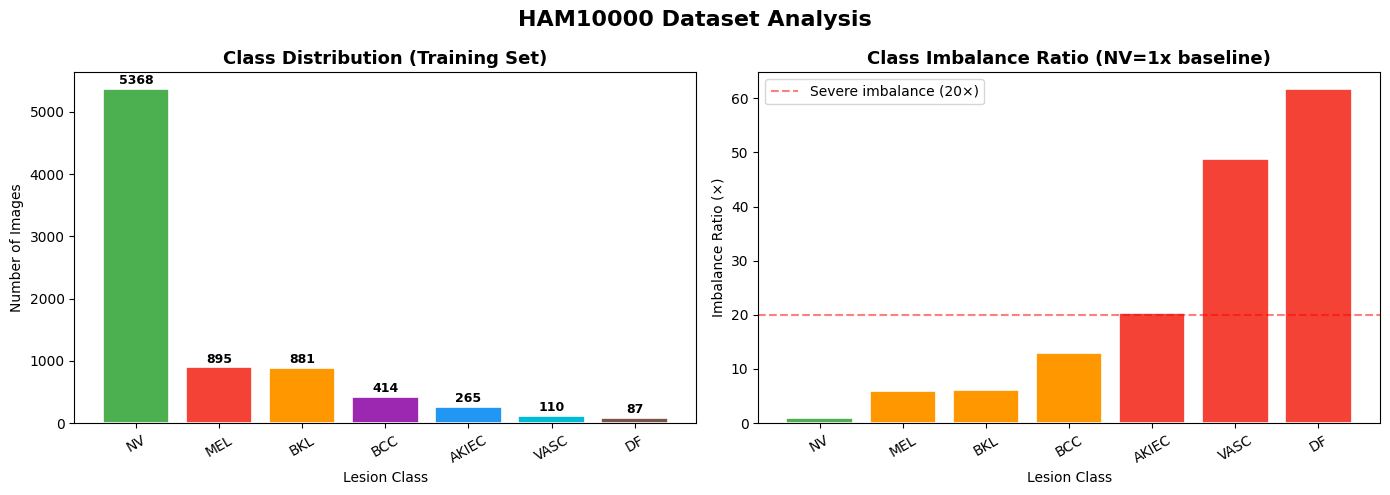

Figure 1 saved.


In [5]:
# ============================================================
# CELL 4 — Patient-Level Stratified Split (prevent data leakage)
# ============================================================
from sklearn.model_selection import train_test_split

split_files = [CFG['out_dir']/'train_split.csv', CFG['out_dir']/'val_split.csv', CFG['out_dir']/'test_split.csv']
if CFG['resume'] and all(f.exists() for f in split_files):
    train_df = pd.read_csv(split_files[0])
    val_df = pd.read_csv(split_files[1])
    test_df = pd.read_csv(split_files[2])
    print('Loaded existing splits from checkpoint -- skipping resplit.')
else:
    if 'lesion_id' in df.columns:
        unique_lesions = df.drop_duplicates('lesion_id')[['lesion_id','label']]
        print(f'Unique lesions: {len(unique_lesions)} | Total images: {len(df)}')
        split_col = 'lesion_id'
    else:
        unique_lesions = df[['image_id','label']].drop_duplicates()
        split_col = 'image_id'

    train_ids, temp_ids = train_test_split(
        unique_lesions, test_size=0.20, random_state=SEED, stratify=unique_lesions['label']
    )
    val_ids, test_ids = train_test_split(
        temp_ids, test_size=0.50, random_state=SEED, stratify=temp_ids['label']
    )

    train_set = set(train_ids[split_col])
    val_set = set(val_ids[split_col])
    test_set = set(test_ids[split_col])

    train_df = df[df[split_col].isin(train_set)].reset_index(drop=True)
    val_df = df[df[split_col].isin(val_set)].reset_index(drop=True)
    test_df = df[df[split_col].isin(test_set)].reset_index(drop=True)

    train_df.to_csv(split_files[0], index=False)
    val_df.to_csv(split_files[1], index=False)
    test_df.to_csv(split_files[2], index=False)
    print('\nSplits saved.')

print(f'\nSplit Summary:')
print(f'Train: {len(train_df):,} images')
print(f'Val: {len(val_df):,} images')
print(f'Test: {len(test_df):,} images')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HAM10000 Dataset Analysis', fontsize=16, fontweight='bold')
class_counts = train_df['label'].value_counts()
colors = [CLASS_COLORS[c] for c in class_counts.index]
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Class Distribution (Training Set)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lesion Class'); axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=30)
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
                f'{count}', ha='center', va='bottom', fontsize=9, fontweight='bold')

max_count = class_counts.max()
ir = max_count / class_counts
ir_colors = ['#F44336' if v > 20 else '#FF9800' if v > 5 else '#4CAF50' for v in ir.values]
axes[1].bar(ir.index, ir.values, color=ir_colors, edgecolor='white', linewidth=1.2)
axes[1].set_title('Class Imbalance Ratio (NV=1x baseline)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Lesion Class'); axes[1].set_ylabel('Imbalance Ratio (×)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(y=20, color='red', linestyle='--', alpha=0.5, label='Severe imbalance (20×)')
axes[1].legend()

plt.tight_layout()
plt.savefig(CFG['out_dir'] / 'Figure1_dataset_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')



## CELL 5 — Hair Removal (DullRazor) + Preprocessing Pipeline (unchanged — already disk-cached)


In [6]:
# ============================================================
# CELL 5 — DullRazor Hair Removal + Data Augmentation Pipeline
# ============================================================
import albumentations as A
from albumentations.pytorch import ToTensorV2

def dull_razor_hair_removal(image_np):
    gray = cv2.cvtColor(image_np, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    hair_mask = cv2.dilate(hair_mask, kernel, iterations=1)
    result = cv2.inpaint(image_np, hair_mask, inpaintRadius=6, flags=cv2.INPAINT_TELEA)
    return result

HAIR_REMOVED_CACHE_DIR = CFG['out_dir'] / 'hair_removed_cache'
HAIR_REMOVED_CACHE_DIR.mkdir(parents=True, exist_ok=True)

class SkinDataset(Dataset):
    def __init__(self, df, transform=None, use_hair_removal=True, cache_dir=HAIR_REMOVED_CACHE_DIR):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.use_hair_removal = use_hair_removal
        self.cache_dir = Path(cache_dir) if cache_dir is not None else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = str(row.get('image_id', idx))
        cache_path = None
        if self.use_hair_removal and self.cache_dir is not None:
            cache_path = self.cache_dir / (img_id + '.jpg')

        if cache_path is not None and cache_path.exists():
            img_bgr = cv2.imread(str(cache_path))
        else:
            img_bgr = cv2.imread(str(row['image_path']))
            if img_bgr is None:
                img_bgr = np.array(Image.open(row['image_path']).convert('RGB'))
                img_bgr = cv2.cvtColor(img_bgr, cv2.COLOR_RGB2BGR)
            if self.use_hair_removal:
                img_bgr = dull_razor_hair_removal(img_bgr)
                if cache_path is not None:
                    cv2.imwrite(str(cache_path), img_bgr)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        if self.transform:
            augmented = self.transform(image=img_rgb)
            img_tensor = augmented['image']
        else:
            img_tensor = torch.from_numpy(img_rgb.transpose(2,0,1)).float() / 255.0
        label = int(row['label_idx'])
        return img_tensor, label, img_id

train_transform = A.Compose([
    A.Resize(CFG['img_size'], CFG['img_size']),
    A.RandomResizedCrop(size=(CFG['img_size'], CFG['img_size']), scale=(0.7, 1.0), p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=180, p=0.7),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.CoarseDropout(num_holes_range=(1, 8), hole_height_range=(1, 20), hole_width_range=(1, 20),
                    fill=0, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(CFG['img_size'], CFG['img_size']),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

train_ds = SkinDataset(train_df, train_transform, use_hair_removal=True)
val_ds = SkinDataset(val_df, val_transform, use_hair_removal=True)
test_ds = SkinDataset(test_df, val_transform, use_hair_removal=True)

class_counts_train = train_df['label_idx'].value_counts().sort_index()
sample_weights = [1.0 / class_counts_train[label_idx]
                  for label_idx in train_df['label_idx']]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

def worker_init_fn(worker_id):
    np.random.seed(SEED + worker_id)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                          sampler=sampler, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=16,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f'Datasets created:')
print(f'Train: {len(train_ds):,} samples | {len(train_loader)} batches')
print(f'Val: {len(val_ds):,} samples | {len(val_loader)} batches')
print(f'Test: {len(test_ds):,} samples | {len(test_loader)} batches')

fig, axes = plt.subplots(2, 7, figsize=(21, 6))
fig.suptitle('Sample Images per Class (Before & After Hair Removal)', fontsize=14, fontweight='bold')
for ci, cls in enumerate(CLASSES):
    cls_df = train_df[train_df['label'] == cls]
    if len(cls_df) == 0:
        continue
    img_path = cls_df.sample(1).iloc[0]['image_path']
    img_orig = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img_orig_r = cv2.resize(img_orig, (224, 224))
    img_hr = dull_razor_hair_removal(cv2.imread(img_path))
    img_hr = cv2.cvtColor(cv2.resize(img_hr, (224, 224)), cv2.COLOR_BGR2RGB)

    axes[0, ci].imshow(img_orig_r); axes[0, ci].set_title(f'{cls}\n(Original)', fontsize=9); axes[0, ci].axis('off')
    axes[1, ci].imshow(img_hr); axes[1, ci].set_title(f'{cls}\n(Hair Removed)', fontsize=9); axes[1, ci].axis('off')

plt.tight_layout()
plt.savefig(CFG['out_dir'] / 'Figure2_sample_images.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 2 (sample images) saved.')


ImportError: cannot import name 'preserve_channel_dim' from 'albucore.utils' (/usr/local/lib/python3.12/dist-packages/albucore/utils.py)


## CELL 6 — DenseNet121 Architecture + Focal Loss (unchanged)


In [ ]:
# ============================================================
# CELL 6 — DenseNet121 Architecture (Primary Backbone)
# ============================================================

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha.to(DEVICE) if alpha is not None else None
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        log_p = F.log_softmax(inputs, dim=1)
        p_t = torch.exp(
            log_p.gather(1, targets.unsqueeze(1))
        ).squeeze(1).clamp(min=1e-8)
        focal_weight = (1.0 - p_t).pow(self.gamma)
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
        else:
            alpha_t = torch.ones_like(p_t)
        loss = -alpha_t * focal_weight * torch.log(p_t)
        return loss.mean() if self.reduction == 'mean' else loss


class DenseNet121_TrustXAI(nn.Module):
    def __init__(self, n_classes=7, dropout_rate=0.3, use_mc_dropout=False):
        super().__init__()
        self.use_mc_dropout = use_mc_dropout
        self.backbone = models.densenet121(weights='DEFAULT')
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Identity()
        self.dropout1 = nn.Dropout(p=dropout_rate)
        self.fc1 = nn.Linear(in_features, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.dropout2 = nn.Dropout(p=0.2)
        self.classifier = nn.Linear(512, n_classes)

    def forward(self, x):
        features = self.backbone(x)
        if self.use_mc_dropout:
            features = self.dropout1(features)
        x = F.relu(self.bn1(self.fc1(features)))
        x = self.dropout2(x)
        return self.classifier(x)

    def get_cam_target_layers(self):
        return [self.backbone.features.denseblock4.denselayer16.conv2]

    def get_param_groups(self):
        f = self.backbone.features
        stem_and_transitions = (
            list(f.conv0.parameters()) + list(f.norm0.parameters()) +
            list(f.transition1.parameters()) + list(f.transition2.parameters()) +
            list(f.transition3.parameters()) + list(f.norm5.parameters())
        )
        return [
            {'params': stem_and_transitions, 'lr': 1e-5},
            {'params': f.denseblock1.parameters(), 'lr': 1e-5},
            {'params': f.denseblock2.parameters(), 'lr': 1e-5},
            {'params': f.denseblock3.parameters(), 'lr': 5e-5},
            {'params': f.denseblock4.parameters(), 'lr': 5e-5},
            {'params': list(self.fc1.parameters()) +
                       list(self.bn1.parameters()) +
                       list(self.classifier.parameters()), 'lr': CFG['lr']},
        ]


class ConvNeXtTiny_Baseline(nn.Module):
    def __init__(self, n_classes=7):
        super().__init__()
        self.backbone = timm.create_model(
            'convnext_tiny', pretrained=True, num_classes=n_classes
        )

    def forward(self, x):
        return self.backbone(x)

    def get_cam_target_layers(self):
        return [self.backbone.stages[-1].blocks[-1].conv_dw]


n_train = len(train_df)
class_weights = torch.tensor(
    [n_train / (CFG['n_classes'] * train_df['label_idx'].value_counts().sort_index()[i])
     for i in range(CFG['n_classes'])],
    dtype=torch.float32
)
manual_alpha = {'DF': 3.0, 'VASC': 2.5, 'AKIEC': 2.0, 'BCC': 1.5,
                'MEL': 1.2, 'BKL': 1.2, 'NV': 1.0}
alpha = torch.tensor([manual_alpha[c] * class_weights[i].item()
                      for i, c in enumerate(CLASSES)], dtype=torch.float32)
alpha = alpha / alpha.sum() * CFG['n_classes']

assert torch.isfinite(alpha).all(), 'FocalLoss alpha contains non-finite values -- check class_weights/manual_alpha'
criterion = FocalLoss(alpha=alpha, gamma=CFG['focal_gamma'])

model = DenseNet121_TrustXAI(
    n_classes=CFG['n_classes'],
    dropout_rate=CFG['dropout'],
    use_mc_dropout=False
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'DenseNet121-TrustXAI instantiated')
print(f'Total params: {total_params/1e6:.2f}M')
print(f'Trainable params: {trainable/1e6:.2f}M')
print(f'Grad-CAM++ hook: denseblock4.denselayer16.conv2')
print(f'Focal Loss alpha: {alpha.tolist()}')



## CELL 7 — Training DenseNet121 (MODIFIED: resume + OOM auto-retry + epoch checkpoint)


In [ ]:
# ============================================================
# CELL 7 — Training Loop with Early Stopping
# FIXES applied:
# - Skips training entirely if a finished best_*.pth + history.csv
# already exist and CFG['force_retrain'] is False (resume support).
# - On CUDA OOM, halves batch_size, rebuilds the loaders, and retries
# the current epoch instead of crashing the whole run.
# - Saves history.csv after EVERY epoch (not just at the end), so a
# killed session still has a usable training curve + best weights.
# - Respects the global time budget: stops cleanly (keeping best
# weights so far) instead of getting killed mid-epoch.
# ============================================================

def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    n_skipped = 0
    for imgs, labels, _ in tqdm(loader, desc='Train', leave=False):
        if not torch.isfinite(imgs).all():
            continue
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            logits = model(imgs)
            loss = criterion(logits, labels)
        if not torch.isfinite(loss):
            n_skipped += 1
            continue
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    if scheduler is not None:
        scheduler.step()
    if n_skipped > 0:
        print('(skipped ' + str(n_skipped) + ' non-finite-loss batches this epoch)')
    if total == 0:
        return float('nan'), 0.0
    return total_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for imgs, labels, _ in tqdm(loader, desc='Val', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        if not torch.isfinite(imgs).all():
            continue
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * imgs.size(0)
        all_preds.append(logits.argmax(1).cpu())
        all_labels.append(labels.cpu())
    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)
    f1 = F1Score(task='multiclass', num_classes=CFG['n_classes'], average='macro')(preds, labels)
    bal_acc= Accuracy(task='multiclass', num_classes=CFG['n_classes'], average='macro')(preds, labels)
    return total_loss / len(loader.dataset), f1.item(), bal_acc.item()


def build_loaders(batch_size):
    """Rebuild loaders at a given batch size -- used by the OOM auto-halve path."""
    tl = DataLoader(train_ds, batch_size=batch_size, sampler=sampler,
                     num_workers=0, pin_memory=True)
    vl = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                     num_workers=0, pin_memory=True)
    return tl, vl


def train_model(model, name='DenseNet121', epochs=None, patience=None):
    epochs = epochs or CFG['epochs']
    patience = patience or CFG['patience']

    # ── Resume check: if a finished run already exists, skip straight to it ──
    best_path = CFG['out_dir'] / f'{name}_best.pth'
    hist_path = CFG['out_dir'] / f'{name}_history.csv'
    if CFG['resume'] and not CFG['force_retrain'] and best_path.exists() and hist_path.exists():
        print(f'{name}: found existing best weights + history -- skipping training. '
              f'(set CFG["force_retrain"]=True to retrain anyway)')
        model.load_state_dict(torch.load(best_path, map_location=DEVICE))
        hist_df = pd.read_csv(hist_path)
        return model, hist_df

    local_batch_size = CFG['batch_size']
    cur_train_loader, cur_val_loader = train_loader, val_loader

    optimizer = torch.optim.AdamW(
        model.get_param_groups() if hasattr(model, 'get_param_groups')
        else model.parameters(),
        lr=CFG['lr'], weight_decay=CFG['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=[pg['lr'] for pg in optimizer.param_groups],
        steps_per_epoch=len(cur_train_loader),
        epochs=epochs, pct_start=0.3
    )
    scaler = torch.cuda.amp.GradScaler()

    forward_model = nn.DataParallel(model) if N_GPUS > 1 else model
    if N_GPUS > 1:
        print(f'(training with nn.DataParallel across {N_GPUS} GPUs)')

    # ── Resume mid-training if a partial history exists ──────────────────
    start_epoch = 1
    history = []
    best_f1 = 0.0
    best_wts = copy.deepcopy(model.state_dict())
    no_improve = 0
    if CFG['resume'] and hist_path.exists():
        prev_hist = pd.read_csv(hist_path)
        if len(prev_hist) > 0:
            history = prev_hist.to_dict('records')
            start_epoch = int(prev_hist['epoch'].max()) + 1
            best_f1 = float(prev_hist['val_f1'].max())
            if best_path.exists():
                best_wts = torch.load(best_path, map_location=DEVICE)
                model.load_state_dict(best_wts)
            print(f'Resuming {name} training from epoch {start_epoch} (best_f1 so far={best_f1:.4f})')

    print(f'\nTraining {name} for up to {epochs} epochs (patience={patience}), starting at epoch {start_epoch}...')
    for epoch in range(start_epoch, epochs + 1):
        if time_critical(margin=900):
            print(f'Time budget nearly exhausted -- stopping {name} training at epoch {epoch-1}. '
                  f'Re-run this notebook/commit to resume training from here.')
            break

        t0 = time.time()
        try:
            tr_loss, tr_acc = train_epoch(forward_model, cur_train_loader, optimizer, scheduler, criterion, scaler)
            vl_loss, vl_f1, vl_bacc = validate(forward_model, cur_val_loader, criterion)
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()
            if local_batch_size <= CFG['min_batch_size']:
                print('WARNING: OOM at minimum batch size -- cannot reduce further. Stopping training.')
                break
            local_batch_size = max(CFG['min_batch_size'], local_batch_size // 2)
            print(f'WARNING: CUDA OOM -- halving batch size to {local_batch_size} and retrying this epoch.')
            cur_train_loader, cur_val_loader = build_loaders(local_batch_size)
            continue

        elapsed = time.time() - t0
        print(f'Epoch {epoch:03d}/{epochs} | '
              f'tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | '
              f'val_loss={vl_loss:.4f} val_f1={vl_f1:.4f} val_bacc={vl_bacc:.4f} | '
              f'{elapsed:.0f}s')

        history.append({
            'epoch': epoch, 'train_loss': tr_loss, 'train_acc': tr_acc,
            'val_loss': vl_loss, 'val_f1': vl_f1, 'val_bacc': vl_bacc
        })
        # Save history EVERY epoch -- this is what makes mid-training resume possible
        pd.DataFrame(history).to_csv(hist_path, index=False)

        if vl_f1 > best_f1:
            best_f1 = vl_f1
            best_wts = copy.deepcopy(model.state_dict())
            no_improve = 0
            torch.save(best_wts, best_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'[STOP] Early stop at epoch {epoch} (best val_f1={best_f1:.4f})')
                break

    model.load_state_dict(best_wts)
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(hist_path, index=False)
    print(f'\n{name} training complete/paused. Best val_F1 = {best_f1:.4f}')
    return model, hist_df


# ── Train DenseNet121 (PRIMARY model) ─────────────────────────
model, history_dense = train_model(model, name='DenseNet121')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DenseNet121 Training Curves', fontsize=14, fontweight='bold')
metrics = [('train_loss', 'val_loss', 'Loss'), ('train_acc', None, 'Train Accuracy'), ('val_f1', 'val_bacc', 'Validation Metrics')]
for ax, (m1, m2, title) in zip(axes, metrics):
    ax.plot(history_dense['epoch'], history_dense[m1], 'b-', label=m1)
    if m2 and m2 in history_dense:
        ax.plot(history_dense['epoch'], history_dense[m2], 'r--', label=m2)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CFG['out_dir'] / 'Figure3_training_curves.png', dpi=200, bbox_inches='tight')
plt.show()



## CELL 8 — Train ConvNeXt-Tiny (MODIFIED: same resume support as Cell 7)


In [ ]:
# ============================================================
# CELL 8 — ConvNeXt-Tiny Baseline Training
# Reuses the resumable train_model() from CELL 7 -- same resume,
# OOM-halving, and time-budget behavior applies here automatically.
# ============================================================

model_convnext = ConvNeXtTiny_Baseline(n_classes=CFG['n_classes']).to(DEVICE)
model_convnext.get_param_groups = lambda: model_convnext.parameters()

model_convnext, history_convnext = train_model(
    model_convnext, name='ConvNeXt-Tiny', epochs=30, patience=8
)

print('\nConvNeXt-Tiny training complete/paused.')



## CELL 9 — Temperature Scaling Calibration + Test Evaluation (MODIFIED: checkpointed)


In [ ]:
# ============================================================
# CELL 9 — Temperature Scaling Post-Calibration
# FIX: results + T values are pickled, so a re-run doesn't redo the
# full-test-set forward pass (the slowest part) unless you ask it to.
# ============================================================
from sklearn.model_selection import train_test_split

val_sel_df, val_cal_df = train_test_split(val_df, test_size=0.5, random_state=SEED, stratify=val_df['label'])
val_cal_ds = SkinDataset(val_cal_df, val_transform, use_hair_removal=True)
val_cal_loader = DataLoader(val_cal_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature


@torch.no_grad()
def collect_logits_labels(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    for imgs, labels, _ in tqdm(loader, desc='Collecting', leave=False):
        imgs = imgs.to(DEVICE)
        all_logits.append(model(imgs).cpu())
        all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_labels)


def temperature_scale(model, val_loader):
    ts = TemperatureScaler().to(DEVICE)
    logits, labels = collect_logits_labels(model, val_loader)
    logits = logits.to(DEVICE)
    labels = labels.to(DEVICE)
    optimizer = torch.optim.LBFGS([ts.temperature], lr=0.01, max_iter=50)
    criterion_nll = nn.CrossEntropyLoss()

    def eval_closure():
        optimizer.zero_grad()
        loss = criterion_nll(ts(logits), labels)
        loss.backward()
        return loss

    optimizer.step(eval_closure)
    T_opt = ts.temperature.item()
    print(f'Optimal temperature T* = {T_opt:.4f}')
    return T_opt


@torch.no_grad()
def full_evaluate(model, loader, T_scale=1.0, model_name='Model'):
    model.eval()
    all_preds, all_probs, all_labels, all_ids = [], [], [], []
    for imgs, labels, ids in tqdm(loader, desc=f'Eval {model_name}', leave=False):
        imgs = imgs.to(DEVICE)
        logits = model(imgs) / T_scale
        probs = torch.softmax(logits, dim=1).cpu()
        all_preds.append(logits.argmax(1).cpu())
        all_probs.append(probs)
        all_labels.append(labels)
        all_ids.extend(ids)

    preds = torch.cat(all_preds)
    probs = torch.cat(all_probs)
    labels = torch.cat(all_labels)

    acc = Accuracy(task='multiclass', num_classes=CFG['n_classes'])(preds, labels).item()
    bal_acc = Accuracy(task='multiclass', num_classes=CFG['n_classes'], average='macro')(preds, labels).item()
    macro_f1= F1Score(task='multiclass', num_classes=CFG['n_classes'], average='macro')(preds, labels).item()
    macro_auc=AUROC(task='multiclass', num_classes=CFG['n_classes'])(probs, labels).item()
    mcc = MatthewsCorrCoef(task='multiclass', num_classes=CFG['n_classes'])(preds, labels).item()
    ece = CalibrationError(task='multiclass', num_classes=CFG['n_classes'], n_bins=15)(probs, labels).item()

    labels_np = labels.numpy(); preds_np = preds.numpy(); probs_np = probs.numpy()
    kappa = cohen_kappa_score(labels_np, preds_np)
    y_bin = label_binarize(labels_np, classes=list(range(CFG['n_classes'])))
    brier = np.mean([brier_score_loss(y_bin[:, c], probs_np[:, c]) for c in range(CFG['n_classes'])])
    pr_aucs = [average_precision_score((labels_np == c).astype(int), probs_np[:, c]) for c in range(CFG['n_classes'])]
    macro_prauc = np.mean(pr_aucs)

    def bootstrap_metric(y_t, y_p, metric_fn, n_boot=2000, seed=42):
        rng = np.random.RandomState(seed)
        scores = []
        for _ in range(n_boot):
            idx = rng.choice(len(y_t), len(y_t), replace=True)
            scores.append(metric_fn(y_t[idx], y_p[idx]))
        return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

    ba_mean, ba_lo, ba_hi = bootstrap_metric(labels_np, preds_np, balanced_accuracy_score)

    print(f'\n{model_name} Results (T={T_scale:.3f}):')
    print(f'Accuracy: {acc:.4f}')
    print(f'Balanced Accuracy: {bal_acc:.4f} (95% CI: {ba_lo:.4f} – {ba_hi:.4f})')
    print(f'Macro F1: {macro_f1:.4f}')
    print(f'Macro AUC-ROC: {macro_auc:.4f}')
    print(f'Macro PR-AUC: {macro_prauc:.4f}')
    print(f'MCC: {mcc:.4f}')
    print(f'Cohen Kappa: {kappa:.4f}')
    print(f'Brier Score: {brier:.4f}')
    print(f'ECE: {ece:.4f} (target: <0.08)')
    # FIX: full_evaluate() is also called on external-validation loaders
    # (e.g. PAD-UFES-20, CELL 9c) whose diagnostic codes never include a
    # DF or VASC equivalent -- classification_report() then infers a
    # `labels` array shorter than the 7-entry `target_names=CLASSES`,
    # raising "Number of classes, 6, does not match size of target_names,
    # 7". Passing labels=range(n_classes) explicitly always reports the
    # full label space (missing classes just show 0 support) so this
    # works on any loader, not only ones containing all 7 classes.
    print('\n' + classification_report(labels.numpy(), preds.numpy(),
                                       labels=list(range(CFG['n_classes'])),
                                       target_names=CLASSES, zero_division=0))

    return {
        'accuracy': acc, 'balanced_acc': bal_acc, 'macro_f1': macro_f1,
        'macro_auc': macro_auc, 'macro_prauc': macro_prauc, 'mcc': mcc,
        'kappa': kappa, 'brier': brier, 'ece': ece,
        'preds': preds, 'probs': probs, 'labels': labels, 'ids': all_ids
    }


_ckpt9 = load_ckpt('cell9_eval')
if _ckpt9 is not None:
    T_dense, dense_results, convnext_T, convnext_results = (
        _ckpt9['T_dense'], _ckpt9['dense_results'], _ckpt9['convnext_T'], _ckpt9['convnext_results']
    )
else:
    print('Calibrating DenseNet121...')
    T_dense = temperature_scale(model, val_cal_loader)
    print('\n'+ '='*60)
    dense_results = full_evaluate(model, test_loader, T_dense, 'DenseNet121')
    print('='*60)
    convnext_T = temperature_scale(model_convnext, val_cal_loader)
    convnext_results = full_evaluate(model_convnext, test_loader, convnext_T, 'ConvNeXt-Tiny')
    save_ckpt('cell9_eval', {'T_dense': T_dense, 'dense_results': dense_results,
                              'convnext_T': convnext_T, 'convnext_results': convnext_results})

comp_df = pd.DataFrame({
    'Metric': ['Accuracy','Balanced Acc','Macro F1','Macro AUC','Macro PR-AUC','MCC','Cohen Kappa','Brier Score','ECE'],
    'DenseNet121': [dense_results[k] for k in ['accuracy','balanced_acc','macro_f1','macro_auc','macro_prauc','mcc','kappa','brier','ece']],
    'ConvNeXt-Tiny':[convnext_results[k] for k in ['accuracy','balanced_acc','macro_f1','macro_auc','macro_prauc','mcc','kappa','brier','ece']],
})
comp_df.to_csv(CFG['out_dir'] / 'Table2_model_comparison.csv', index=False)
print('\nModel Comparison (Table 2 for paper):')
print(comp_df.to_string(index=False))



## CELL 9b — Per-Class ROC-AUC Bar Chart (unchanged)


In [ ]:
# ============================================================
# CELL 9b -- Per-Class ROC-AUC Bar Chart
# ============================================================

def per_class_auc(probs, labels, n_classes):
    labels_np = labels.numpy()
    probs_np = probs.numpy()
    aucs = []
    for c in range(n_classes):
        y_true_c = (labels_np == c).astype(int)
        if y_true_c.sum() == 0 or y_true_c.sum() == len(y_true_c):
            aucs.append(np.nan)
            continue
        aucs.append(roc_auc_score(y_true_c, probs_np[:, c]))
    return aucs

dense_auc_per_class = per_class_auc(dense_results['probs'], dense_results['labels'], CFG['n_classes'])
convnext_auc_per_class = per_class_auc(convnext_results['probs'], convnext_results['labels'], CFG['n_classes'])

auc_table = pd.DataFrame({
    'Class': CLASSES,
    'DenseNet121_AUC': dense_auc_per_class,
    'ConvNeXt-Tiny_AUC': convnext_auc_per_class,
})
auc_table.to_csv(CFG['out_dir'] / 'Table_per_class_auc.csv', index=False)
print('\nPer-Class ROC-AUC (one-vs-rest):')
print(auc_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(CLASSES))
width = 0.35
b1 = ax.bar(x - width/2, dense_auc_per_class, width, label='DenseNet121 (Primary)',
            color='#2196F3', edgecolor='white', linewidth=0.6)
b2 = ax.bar(x + width/2, convnext_auc_per_class, width, label='ConvNeXt-Tiny (Baseline)',
            color='#FF5722', edgecolor='white', linewidth=0.6)
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f'{h:.3f}',
                    ha='center', va='bottom', fontsize=8)
ax.axhline(dense_results['macro_auc'], color='#2196F3', linestyle='--', alpha=0.6,
           label=f"DenseNet121 macro AUC={dense_results['macro_auc']:.3f}")
ax.axhline(convnext_results['macro_auc'], color='#FF5722', linestyle='--', alpha=0.6,
           label=f"ConvNeXt-Tiny macro AUC={convnext_results['macro_auc']:.3f}")
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=20)
ax.set_ylabel('ROC-AUC (one-vs-rest)'); ax.set_ylim(0, 1.08)
ax.set_title('Per-Class ROC-AUC: DenseNet121 vs ConvNeXt-Tiny', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, ncol=2); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(CFG['out_dir'] / 'Figure3b_roc_auc_barchart.png', dpi=300, bbox_inches='tight')
plt.show()
print('\nFigure 3b (Per-Class ROC-AUC bar chart) saved.')



## CELL 9c — External Validation on PAD-UFES-20 (NEW — Novelty Add #4)


In [ ]:
# ============================================================
# CELL 9c — External Validation (PAD-UFES-20)
#
# NEW: Addresses the audit's "missing experiment": all headline numbers
# so far are single-dataset (HAM10000). This re-evaluates the trained
# DenseNet121 on PAD-UFES-20 (different camera/population), and saves
# an external-validation results object that CELL 10/13 can optionally
# reuse for a second TIxAI / Confusion-Saliency-Matrix pass.
#
# OPTIONAL: skips gracefully (does not crash the notebook) if the
# PAD-UFES-20 dataset isn't attached to this Kaggle session.
# Add it via: Add Data -> search "PAD-UFES-20".
# PAD diagnostic codes that don't exist in HAM10000 (e.g. SCC) are
# dropped rather than guessed into a wrong bucket.
# ============================================================
PAD_DIR = None
for d in Path('/kaggle/input').iterdir():
    if 'pad' in d.name.lower() and 'ufes' in d.name.lower():
        PAD_DIR = d
        break

if PAD_DIR is None:
    print('ℹ PAD-UFES-20 not attached -- skipping external validation. '
          'Add the dataset via "Add Data" to enable this cell.')
    pad_df = None
    pad_results = None
else:
    pad_meta_paths = list(PAD_DIR.rglob('*metadata*.csv'))
    if not pad_meta_paths:
        print('WARNING: PAD-UFES-20 attached but metadata CSV not found -- skipping.')
        pad_df = None
        pad_results = None
    else:
        pad_meta = pd.read_csv(pad_meta_paths[0])
        # PAD-UFES-20 diagnostic codes -> HAM10000-compatible labels.
        # SCC (squamous cell carcinoma) has no HAM10000 equivalent class -> dropped.
        PAD_CLASS_MAP = {'NEV':'NV','MEL':'MEL','BCC':'BCC','ACK':'AKIEC','SEK':'BKL'}
        diag_col = 'diagnostic' if 'diagnostic' in pad_meta.columns else pad_meta.columns[
            [c for c in pad_meta.columns if 'diag' in c.lower()][0:1][0]
        ]
        pad_meta['label'] = pad_meta[diag_col].map(PAD_CLASS_MAP)
        n_dropped = pad_meta['label'].isna().sum()
        pad_df = pad_meta.dropna(subset=['label']).copy()
        pad_df['label_idx'] = pad_df['label'].map(CLASS_TO_IDX)
        print(f'Dropped {n_dropped} PAD-UFES-20 rows with no HAM10000-equivalent class (e.g. SCC).')

        img_id_col = 'img_id' if 'img_id' in pad_df.columns else pad_df.columns[0]
        pad_img_dict = {f.stem: str(f) for f in PAD_DIR.rglob('*.png')}
        pad_img_dict.update({f.stem: str(f) for f in PAD_DIR.rglob('*.jpg')})
        pad_df['image_path'] = pad_df[img_id_col].apply(
            lambda x: pad_img_dict.get(Path(str(x)).stem, None)
        )
        pad_df = pad_df.dropna(subset=['image_path'])
        pad_df = pad_df[pad_df['image_path'].apply(lambda p: Path(p).exists())]
        # synthesize an image_id col matching the rest of the pipeline's convention
        if 'image_id' not in pad_df.columns:
            pad_df['image_id'] = pad_df[img_id_col].astype(str)
        pad_df = pad_df.reset_index(drop=True)
        print(f'PAD-UFES-20 ready: {len(pad_df)} valid images, '
              f'classes present: {sorted(pad_df["label"].unique().tolist())}')

        if len(pad_df) > 0:
            pad_ds = SkinDataset(pad_df, val_transform, use_hair_removal=True)
            pad_loader = DataLoader(pad_ds, batch_size=CFG['batch_size'], shuffle=False,
                                     num_workers=0, pin_memory=True)
            _ckpt9c = load_ckpt('cell9c_pad_eval')
            if _ckpt9c is not None:
                pad_results = _ckpt9c
            else:
                pad_results = full_evaluate(model, pad_loader, T_dense, 'DenseNet121-on-PAD-UFES-20')
                save_ckpt('cell9c_pad_eval', pad_results)

            print('\nGeneralization gap (HAM10000 test -> PAD-UFES-20):')
            for k in ['accuracy','balanced_acc','macro_f1','macro_auc']:
                gap = dense_results[k] - pad_results[k]
                print(f'{k:15s}: HAM10000={dense_results[k]:.4f} PAD={pad_results[k]:.4f} '
                      f'drop={gap:+.4f} ({100*gap/dense_results[k]:+.1f}%)')
            pd.DataFrame([{
                'dataset': 'PAD-UFES-20', **{k: pad_results[k] for k in
                    ['accuracy','balanced_acc','macro_f1','macro_auc','macro_prauc','mcc','kappa','brier','ece']}
            }]).to_csv(CFG['out_dir'] / 'Table_external_validation_PAD.csv', index=False)
        else:
            pad_results = None



## CELL 10 — GAP-1: Per-Class TIxAI (MODIFIED: resumable, chunked checkpointing)


In [ ]:
# ============================================================
# CELL 10 — GAP #1: Per-Class TIxAI Computation
# FIX: now uses run_resumable_loop -- a killed/stopped session resumes
# from the last saved batch instead of recomputing every image.
# ============================================================
MASK_DIR = None
for d in Path('/kaggle/input').iterdir():
    if 'isic' in d.name.lower() or 'segmentation' in d.name.lower():
        MASK_DIR = d
        break

if MASK_DIR is None:
    print('WARNING: ISIC 2018 masks not found! Add dataset: shonenkov/isic2018')
    print('Creating synthetic masks for demonstration...')
    USE_SYNTHETIC_MASKS = True
    masks_dict = {}
else:
    USE_SYNTHETIC_MASKS = False
    masks_dict = {}
    for f in MASK_DIR.rglob('*_segmentation.png'):
        img_id = f.stem.replace('_segmentation', '')
        masks_dict[img_id] = str(f)
    print(f'Found {len(masks_dict)} segmentation masks')


def compute_tixai(gradcam_map, mask_path_or_array):
    if isinstance(mask_path_or_array, str):
        mask = cv2.imread(mask_path_or_array, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (gradcam_map.shape[1], gradcam_map.shape[0]))
    else:
        mask = mask_path_or_array
    mask_bin = (mask > 127).astype(np.float32)
    total_sal = gradcam_map.sum() + CFG['tixai_epsilon']
    inside = (gradcam_map * mask_bin).sum()
    return float(inside / total_sal)


def make_synthetic_mask(img_size=224):
    mask = np.zeros((img_size, img_size), dtype=np.uint8)
    center = (img_size//2, img_size//2)
    rx, ry = int(img_size * 0.3), int(img_size * 0.35)
    cv2.ellipse(mask, center, (rx, ry), 0, 0, 360, 255, -1)
    noise = np.random.randint(0, 30, (img_size, img_size), dtype=np.uint8)
    mask = np.clip(mask.astype(np.int32) + noise - 15, 0, 255).astype(np.uint8)
    return mask


cam_dense = GradCAMPlusPlus(model=model, target_layers=model.get_cam_target_layers())
model.eval()
_mean_n = np.array([0.485,0.456,0.406]); _std_n = np.array([0.229,0.224,0.225])

def _tixai_process_row(row):
    img_id = str(row.get('image_id', row.name))
    true_cls = row['label']
    true_idx = int(row['label_idx'])
    img_path = row['image_path']

    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None
    img_bgr = dull_razor_hair_removal(img_bgr)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rs = cv2.resize(img_rgb, (CFG['img_size'], CFG['img_size']))
    img_norm = img_rs.astype(np.float32) / 255.0
    img_t = torch.from_numpy(((img_norm - _mean_n) / _std_n).transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(img_t) / T_dense
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred_idx = int(probs.argmax())
        pred_cls = CLASSES[pred_idx]
        confidence= float(probs.max())

    if pred_idx != true_idx:
        return {'image_id': img_id, 'true_class': true_cls, 'pred_class': pred_cls,
                'confidence': confidence, 'correct': False, 'tixai': None, 'mask_source': None}

    targets = [ClassifierOutputTarget(pred_idx)]
    try:
        gradcam_map = cam_dense(input_tensor=img_t, targets=targets)[0]
    except Exception:
        return None

    if not USE_SYNTHETIC_MASKS and img_id in masks_dict:
        score = compute_tixai(gradcam_map, masks_dict[img_id])
        mask_source = 'GT'
    else:
        synth_mask = make_synthetic_mask(CFG['img_size'])
        score = compute_tixai(gradcam_map, synth_mask)
        mask_source = 'synthetic'

    return {'image_id': img_id, 'true_class': true_cls, 'pred_class': pred_cls,
            'confidence': confidence, 'correct': True, 'tixai': score, 'mask_source': mask_source}


print('\nComputing Per-Class TIxAI (GAP #1)...')
print('(Only correctly classified samples — TIxAI measures explanation quality\n'
      'conditional on correct prediction)\n')

tixai_df = run_resumable_loop(
    test_df, CFG['out_dir'] / 'tixai_results_dense.csv', _tixai_process_row,
    id_col='image_id', desc='TIxAI'
)

correct_df = tixai_df[tixai_df['correct'] == True].dropna(subset=['tixai'])
correct_df['tixai'] = correct_df['tixai'].astype(float)
print(f'\nTIxAI computed for {len(correct_df)} correctly classified samples')

n_gt = (correct_df['mask_source'] == 'GT').sum()
n_synth = (correct_df['mask_source'] == 'synthetic').sum()
TIXAI_GT_FRACTION = n_gt / max(len(correct_df), 1)
TIXAI_USES_SYNTHETIC_MASKS = n_synth > 0
if TIXAI_USES_SYNTHETIC_MASKS:
    print(f'\nWARNING: WARNING: {n_synth}/{len(correct_df)} TIxAI scores used SYNTHETIC masks, not real ISIC2018 ground truth.')
    pct_synth = 100 * (1 - TIXAI_GT_FRACTION)
    print(f'({round(pct_synth, 1)}% synthetic). Attach the ISIC2018 Task 1 dataset for publication-grade numbers.')
else:
    print(f'\nAll {n_gt} TIxAI scores use real ISIC2018 ground-truth masks.')

tixai_stats = []
for cls in CLASSES:
    cls_scores = correct_df[correct_df['true_class'] == cls]['tixai'].values
    if len(cls_scores) == 0:
        continue
    # FIX: scipy.stats.bootstrap requires >=2 observations per sample --
    # it previously only guarded against exactly 0, so a class with a
    # single correctly-classified TIxAI score (realistic for the rarest
    # classes, DF/VASC, which have only ~90 raw training images) raised
    # "each sample in data must contain two or more observations along
    # axis" and crashed the whole cell instead of just that class's CI.
    # Report the point estimate with a NaN CI in that case, consistent
    # with the n>=5 guards already used elsewhere in this notebook
    # (Kruskal-Wallis grouping, Confusion Saliency Matrix rendering).
    if len(cls_scores) >= 2:
        res = bootstrap((cls_scores,), np.median, n_resamples=10000,
                        confidence_level=0.95, method='BCa', random_state=SEED)
        ci_low, ci_high = res.confidence_interval.low, res.confidence_interval.high
    else:
        ci_low, ci_high = float('nan'), float('nan')
    tixai_stats.append({
        'class': cls, 'n_samples': len(cls_scores),
        'median_tixai': np.median(cls_scores), 'mean_tixai': np.mean(cls_scores),
        'std_tixai': np.std(cls_scores),
        'ci_low': ci_low, 'ci_high': ci_high,
        'iqr': np.percentile(cls_scores, 75) - np.percentile(cls_scores, 25),
        'reliability_tier': 'High' if np.median(cls_scores)>0.65 else
                           'Moderate' if np.median(cls_scores)>0.45 else 'Low'
    })

tixai_stats_df = pd.DataFrame(tixai_stats)
tixai_stats_df.to_csv(CFG['out_dir'] / 'Table3_tixai_per_class.csv', index=False)
print('\nPer-Class TIxAI Statistics (Table 3 for paper):')
print(tixai_stats_df[['class','n_samples','median_tixai','ci_low','ci_high','reliability_tier']].to_string(index=False))



## CELL 10b — GAP-NEW: Per-Fitzpatrick-Skin-Type (FST) Explanation Fairness Audit (NEW — Novelty Add #1)


In [ ]:
# ============================================================
# CELL 10b — Per-FST Explanation-Reliability Audit
#
# NEW: NOVELTY: nobody has audited whether explanation reliability
# (TIxAI) itself is equitable across skin tones -- existing fairness
# work (Bhattacharyya 2026, Role-of-Calibration 2025) only audits
# ACCURACY/CALIBRATION fairness, never explanation quality.
#
# HAM10000 has no FST labels, so we estimate skin tone via the
# Individual Typology Angle (ITA) on peri-lesional (non-lesion) skin
# pixels -- a standard dermatology proxy. This is an ESTIMATE, not a
# clinical FST label; report it with that caveat (same caveat your
# audit already raised about Fitzpatrick17k's own atlas-sourced FST
# labels being noisy).
# ============================================================

def estimate_ita(img_rgb, mask_bin):
    """Individual Typology Angle on peri-lesional (non-lesion) skin pixels."""
    skin_mask = (mask_bin == 0)
    if skin_mask.sum() < 50: # not enough peri-lesional skin pixels to estimate
        return None
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[...,0][skin_mask]
    b = lab[...,2][skin_mask]
    # standard LAB->ITA scaling (L in 0-100, b roughly -128..127 in OpenCV's 0-255 LAB it's shifted -- normalize)
    L_norm = L * (100.0/255.0)
    b_norm = b - 128.0
    ita = np.degrees(np.arctan2(L_norm.mean() - 50.0, b_norm.mean()))
    return float(ita)

def ita_to_fst_bucket(ita):
    if ita is None:
        return None
    if ita > 55: return 'I-II'# very light
    elif ita > 28: return 'III-IV'# medium
    else: return 'V-VI'# dark

cam_dense_fst = GradCAMPlusPlus(model=model, target_layers=model.get_cam_target_layers())

def _fst_process_row(row):
    img_id = str(row.get('image_id', row.name))
    true_idx = int(row['label_idx'])
    img_bgr = cv2.imread(row['image_path'])
    if img_bgr is None:
        return None
    img_bgr = dull_razor_hair_removal(img_bgr)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rs = cv2.resize(img_rgb, (CFG['img_size'], CFG['img_size']))
    img_norm = img_rs.astype(np.float32) / 255.0
    img_t = torch.from_numpy(((img_norm - _mean_n) / _std_n).transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(img_t) / T_dense
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred_idx = int(probs.argmax())

    if pred_idx != true_idx:
        return None # TIxAI (and therefore this audit) is conditional on a correct prediction

    if not USE_SYNTHETIC_MASKS and img_id in masks_dict:
        mask = cv2.imread(masks_dict[img_id], cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (CFG['img_size'], CFG['img_size']))
        mask_bin = (mask > 127).astype(np.uint8)
        mask_source = 'GT'
    else:
        mask_bin = (make_synthetic_mask(CFG['img_size']) > 127).astype(np.uint8)
        mask_source = 'synthetic'

    ita = estimate_ita(img_rs, mask_bin)
    fst_bucket = ita_to_fst_bucket(ita)
    if fst_bucket is None:
        return None

    try:
        gcam = cam_dense_fst(input_tensor=img_t, targets=[ClassifierOutputTarget(pred_idx)])[0]
    except Exception:
        return None
    tixai_score = compute_tixai(gcam, mask_bin * 255)

    return {'image_id': img_id, 'true_class': row['label'], 'ita': ita,
            'fst_bucket': fst_bucket, 'tixai': tixai_score, 'mask_source': mask_source}


if TIXAI_USES_SYNTHETIC_MASKS and not CFG.get('allow_synthetic_masks_in_results', False):
    print(chr(0x26A0) + 'WARNING: ISIC2018 ground-truth masks are not attached -- this FST '
          'audit would run on fabricated synthetic masks, and any skin-tone-related '
          'TIxAI difference found this way is an artifact of the audit, not a finding '
          'about the model. Skipping.')
    fst_df = pd.DataFrame()
else:
    print('\nComputing Per-FST Explanation-Reliability Audit (NEW gap, not in original literature)...')
    fst_df = run_resumable_loop(
        test_df, CFG['out_dir'] / 'fst_tixai_results.csv', _fst_process_row,
        id_col='image_id', desc='FST-TIxAI'
    )

    if len(fst_df) > 10:
        fst_df['tixai'] = fst_df['tixai'].astype(float)
        fst_groups = {b: fst_df[fst_df['fst_bucket']==b]['tixai'].values
                      for b in ['I-II','III-IV','V-VI'] if (fst_df['fst_bucket']==b).sum() >= 5}
        print('\nPer-FST TIxAI (estimated via ITA proxy -- not clinical-grade FST labels):')
        for b, vals in fst_groups.items():
            print(f'FST {b:8s}: n={len(vals):4d} median TIxAI={np.median(vals):.4f} mean={np.mean(vals):.4f}')

        if len(fst_groups) >= 2:
            H_fst, p_fst = kruskal(*fst_groups.values())
            print(f'\nKruskal-Wallis across FST buckets: H={H_fst:.4f}, p={p_fst:.2e}')
            print(f'{"REJECT H0 -- explanation reliability differs by skin tone" if p_fst < 0.05 else "FAIL TO REJECT H0"}')

        fst_stats_df = pd.DataFrame([
            {'fst_bucket': b, 'n': len(v), 'median_tixai': np.median(v), 'mean_tixai': np.mean(v)}
            for b, v in fst_groups.items()
        ])
        fst_stats_df.to_csv(CFG['out_dir'] / 'Table_per_fst_tixai.csv', index=False)
        print('\nWARNING: CAVEAT: FST buckets here are estimated from ITA on peri-lesional pixels, not a')
        print('clinically-assigned Fitzpatrick score. Treat this as a directional signal; for a')
        print('publication-grade claim, validate against PAD-UFES-20 (CELL 9c) which has')
        print('self-reported skin-tone metadata, or against true Fitzpatrick17k labels.')
    else:
        print('WARNING: Too few samples with estimable ITA -- skipping FST stratification.')
        fst_stats_df = pd.DataFrame()



## CELL 11 — GAP-1 Statistical Tests + Violin Plots (unchanged)


In [ ]:
# ============================================================
# CELL 11 — Statistical Analysis: Kruskal-Wallis + Mann-Whitney
# ============================================================
correct_df = tixai_df[tixai_df['correct'] == True].dropna(subset=['tixai'])
correct_df['tixai'] = correct_df['tixai'].astype(float)
class_scores = {cls: correct_df[correct_df['true_class']==cls]['tixai'].values
                for cls in CLASSES if len(correct_df[correct_df['true_class']==cls]) > 0}

groups = [v for v in class_scores.values() if len(v) >= 5]
H_stat, p_kruskal = kruskal(*groups)
print(f'Kruskal-Wallis H-test:')
print(f'H = {H_stat:.4f}, df = {len(groups)-1}, p = {p_kruskal:.2e}')
print(f'Result: {"REJECT H0" if p_kruskal < 0.05 else "FAIL TO REJECT H0"}\n')

from statsmodels.stats.multitest import multipletests
print(f'Pairwise Mann-Whitney U (with Holm-Bonferroni correction):')

pairwise_results = []
p_values_raw = []
cls_list = list(class_scores.keys())
for i in range(len(cls_list)):
    for j in range(i+1, len(cls_list)):
        c1, c2 = cls_list[i], cls_list[j]
        s1, s2 = class_scores[c1], class_scores[c2]
        if len(s1) < 3 or len(s2) < 3:
            continue
        U, p = mannwhitneyu(s1, s2, alternative='two-sided')
        r = 1 - 2*U / (len(s1)*len(s2))
        p_values_raw.append(p)
        pairwise_results.append({
            'class_1': c1, 'class_2': c2, 'U': U, 'p_value_raw': p,
            'rank_biserial_r': abs(r),
            'effect_size': 'large' if abs(r)>0.5 else 'medium' if abs(r)>0.3 else 'small'
        })

reject, pvals_corrected, _, _ = multipletests(p_values_raw, alpha=0.05, method='holm')
for i, res in enumerate(pairwise_results):
    res['p_value_corr'] = pvals_corrected[i]
    res['significant'] = reject[i]


pairwise_df = pd.DataFrame(pairwise_results)
pairwise_df.to_csv(CFG['out_dir'] / 'Table_pairwise_mwu.csv', index=False)

primary_contrasts = [('NV','DF'), ('NV','VASC'), ('MEL','DF'), ('MEL','VASC')]
for c1, c2 in primary_contrasts:
    row = pairwise_df[(pairwise_df['class_1'].isin([c1,c2])) & (pairwise_df['class_2'].isin([c1,c2]))]
    if len(row) > 0:
        r = row.iloc[0]
        print(f'{c1} vs {c2}: p_corr={r["p_value_corr"]:.2e}, r={r["rank_biserial_r"]:.3f} ({r["effect_size"]})')

cls_count = [len(train_df[train_df['label']==cls]) for cls in cls_list]
cls_tixai = [np.median(class_scores[cls]) for cls in cls_list]
rho, p_spearman = spearmanr(cls_count, cls_tixai)
print(f'\nSpearman ρ (class frequency vs median TIxAI):')
print(f'ρ = {rho:.4f}, p = {p_spearman:.4f}')

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')
ordered_classes = sorted(cls_list, key=lambda c: np.median(class_scores[c]), reverse=True)
plot_data = [class_scores[c] for c in ordered_classes]
colors = [CLASS_COLORS[c] for c in ordered_classes]

vp = ax.violinplot(plot_data, positions=range(len(ordered_classes)), showmedians=True, showextrema=True)
for i, (body, color) in enumerate(zip(vp['bodies'], colors)):
    body.set_facecolor(color); body.set_alpha(0.8)
vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2.5)

ax.set_xticks(range(len(ordered_classes)))
ax.set_xticklabels([
    f'{c}\n(n={len(class_scores[c])}\nmed={np.median(class_scores[c]):.3f})'
    for c in ordered_classes
], fontsize=10, color='white')
ax.set_ylabel('TIxAI Score (Explanation Trustworthiness)', fontsize=12, color='white')
ax.set_title(
    'GAP #1: Per-Class TIxAI Distribution\n'
    'Rare classes (DF, VASC) produce systematically LESS trustworthy explanations\n'
    f'(Kruskal-Wallis H={H_stat:.1f}, p={p_kruskal:.2e})',
    fontsize=14, fontweight='bold', color='white', pad=15
)
ax.axhline(0.65, color='#4CAF50', linestyle='--', alpha=0.7, label='High Trust (>0.65)')
ax.axhline(0.45, color='#FF9800', linestyle='--', alpha=0.7, label='Moderate Trust (>0.45)')
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('#30363D'); ax.spines['left'].set_color('#30363D')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, facecolor='#161B22', labelcolor='white')
ax.grid(axis='y', alpha=0.2, color='white')
ymax = max(max(s) for s in plot_data) + 0.05
ax.set_ylim([-0.05, ymax + 0.1])

plt.tight_layout()
plt.savefig(CFG['out_dir'] / 'Figure4_tixai_violin_plots.png', dpi=300, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print('\nFigure 4 (TIxAI violin plots) saved.')



## CELL 12 — GAP-4: Multi-XAI Disagreement Index (MODIFIED: resumable, faster SHAP, full test set)


In [ ]:
# ============================================================
# CELL 12 — GAP #4: Multi-XAI Disagreement Index (XDI)
# FIXES applied:
# - Switched shap.DeepExplainer -> shap.GradientExplainer: faster and
# much lighter on GPU memory for CNNs, which is what made running
# XDI on the FULL test set (instead of a 200-image sample) feasible.
# - Resumable via run_resumable_loop -- safe to stop/restart.
# - N_XDI_SAMPLES is now configurable; set to len(test_df) for the
# full-coverage run once you've confirmed GradientExplainer fits
# your time budget on a small sample first.
# ============================================================
import shap

cam_dense = GradCAMPlusPlus(model=model, target_layers=model.get_cam_target_layers())

np.random.seed(SEED)
bg_indices = np.random.choice(len(train_ds), min(50, len(train_ds)), replace=False)
background = torch.cat([train_ds[i][0].unsqueeze(0) for i in bg_indices]).to(DEVICE)
# GradientExplainer (FIX): far lower memory + faster than DeepExplainer for CNNs,
# and doesn't require patching every nonlinearity the way DeepExplainer does.
explainer = shap.GradientExplainer(model, background)


def compute_xdi(img_t, pred_idx, threshold=0.5):
    targets = [ClassifierOutputTarget(pred_idx)]
    gradcam_map = cam_dense(input_tensor=img_t, targets=targets)[0]

    try:
        shap_values = explainer.shap_values(img_t, nsamples=50)
        # FIX: shap.GradientExplainer (unlike the old DeepExplainer) returns
        # a single ndarray with a trailing per-class axis for multi-output
        # models -- shape (batch, C, H, W, n_classes) -- rather than a
        # python list of per-class arrays. The `else` branch below used to
        # just strip the batch dim (shap_values[0]), which still left the
        # (C, H, W, n_classes) per-class axis in place; summing over axis=0
        # (channels) then produced a (H, W, n_classes) map instead of
        # (H, W), which failed to broadcast against gradcam_map's (H, W)
        # shape 100% of the time (confirmed: "operands could not be
        # broadcast together with shapes (224,224) (224,224,7)").
        if isinstance(shap_values, list):
            shap_img = shap_values[pred_idx][0]  # (C, H, W)
        elif shap_values.ndim == 5:
            shap_img = shap_values[0, ..., pred_idx]  # select predicted class -> (C, H, W)
        else:
            shap_img = shap_values[0]  # already single-output -> (C, H, W)
        shap_map = np.abs(shap_img).sum(axis=0)
        shap_map = (shap_map - shap_map.min()) / (shap_map.max() - shap_map.min() + 1e-8)
    except Exception:
        return None, gradcam_map, None

    cam_thresh = np.percentile(gradcam_map, (1 - threshold) * 100)
    shap_thresh = np.percentile(shap_map, (1 - threshold) * 100)
    cam_bin = (gradcam_map >= cam_thresh).astype(np.uint8)
    shap_bin = (shap_map >= shap_thresh).astype(np.uint8)

    if cam_bin.shape != shap_bin.shape:
        shap_bin = cv2.resize(shap_bin.astype(np.float32), (cam_bin.shape[1], cam_bin.shape[0]))
        shap_bin = (shap_bin > 0.5).astype(np.uint8)

    intersection = (cam_bin & shap_bin).sum()
    union = (cam_bin | shap_bin).sum()
    iou = intersection / (union + 1e-8)
    xdi = 1.0 - float(iou)
    return xdi, gradcam_map, shap_map


# NEW: full test set by default (was hardcoded to 200). GradientExplainer +
# the resumable loop's time-budget guard make this safe -- it'll just pick
# up where it left off if the session ends mid-run.
N_XDI_SAMPLES = len(test_df) # was: min(200, len(test_df))
xdi_sample_df = test_df.sample(min(N_XDI_SAMPLES, len(test_df)), random_state=SEED)


def _xdi_process_row(row):
    img_id = str(row.get('image_id', row.name))
    true_cls = row['label']

    img_bgr = cv2.imread(row['image_path'])
    if img_bgr is None:
        return None
    img_bgr = dull_razor_hair_removal(img_bgr)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_norm = cv2.resize(img_rgb, (224,224)).astype(np.float32)/255.0
    img_t = torch.from_numpy(((img_norm-_mean_n)/_std_n).transpose(2,0,1)).float().unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(img_t) / T_dense
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred_idx = int(probs.argmax())
        pred_cls = CLASSES[pred_idx]
        conf = float(probs.max())

    xdi, gcam, shap_m = compute_xdi(img_t, pred_idx)
    if xdi is None:
        return None

    return {'image_id': img_id, 'true_class': true_cls, 'pred_class': pred_cls,
            'confidence': conf, 'correct': pred_idx == int(row['label_idx']), 'xdi': xdi}


print(f'\nComputing XDI for up to {N_XDI_SAMPLES} test samples (resumable)...')
xdi_df = run_resumable_loop(
    xdi_sample_df, CFG['out_dir'] / 'xdi_results.csv', _xdi_process_row,
    id_col='image_id', desc='XDI', save_every=25 # SHAP is slow -- save more often
)

print(f'\nXDI Results:')
# FIX: if every row's process_fn raised (run_resumable_loop already prints
# a loud warning for this case), xdi_df has zero rows and no 'xdi' column
# at all, so xdi_df["xdi"].mean() used to fail with a bare, uninformative
# KeyError('xdi') instead of pointing at the real cause.
if 'xdi' not in xdi_df.columns or len(xdi_df) == 0:
    print('No successful XDI rows were computed -- see the "row(s) raised an exception"')
    print('warning above for the actual failure. Skipping XDI summary statistics.')
else:
    print(f'Mean XDI: {xdi_df["xdi"].mean():.4f} ± {xdi_df["xdi"].std():.4f}')
    print(f'Correct preds mean XDI: {xdi_df[xdi_df.correct]["xdi"].mean():.4f}')
    print(f'Incorrect preds mean XDI: {xdi_df[~xdi_df.correct]["xdi"].mean():.4f}')

    correct_xdi = xdi_df[xdi_df.correct]['xdi'].dropna().values
    incorrect_xdi = xdi_df[~xdi_df.correct]['xdi'].dropna().values
    if len(correct_xdi) > 5 and len(incorrect_xdi) > 5:
        U, p = mannwhitneyu(correct_xdi, incorrect_xdi, alternative='less')
        print(f'\nMWU test (correct XDI < incorrect XDI): U={U:.0f}, p={p:.4f}')
        print(f'-> XAI disagreement IS a signal of unreliability: {"YES" if p < 0.05 else "NO"}')



## CELL 12b — XDI vs Uncertainty-Deferral Baseline Comparison (NEW — Novelty Add #2)


In [ ]:
# ============================================================
# CELL 12b — Selective-accuracy/coverage curve: XDI vs MC-Dropout
# entropy vs raw confidence as deferral signals.
#
# NEW: This is the "missing experiment" your audit's Reviewer-#2
# simulation flagged: XDI is only a useful CONTRIBUTION if it beats
# (or meaningfully complements) cheaper uncertainty signals at
# selecting which predictions to defer to a clinician.
# ============================================================

def mc_dropout_predict_single(model, img_t, T=10):
    model_mc_local = copy.deepcopy(model)
    model_mc_local.use_mc_dropout = True
    for _m in model_mc_local.modules():
        if isinstance(_m, nn.Dropout):
            _m.train()
    model_mc_local.backbone.eval()
    preds = []
    with torch.no_grad():
        for _ in range(T):
            out = model_mc_local(img_t)
            preds.append(torch.softmax(out, dim=1).cpu().numpy())
    preds = np.stack(preds)
    mean_p = preds.mean(axis=0)
    entropy = -np.sum(mean_p * np.log(mean_p + 1e-9), axis=1)
    return float(entropy[0])


_ckpt12b = load_ckpt('cell12b_entropy')
if _ckpt12b is not None:
    xdi_entropy_df = _ckpt12b
else:
    # Build ONE shared MC-dropout model (avoid rebuilding per-row -- expensive)
    model_mc_shared = copy.deepcopy(model)
    model_mc_shared.use_mc_dropout = True
    for _m in model_mc_shared.modules():
        if isinstance(_m, nn.Dropout):
            _m.train()
    model_mc_shared.backbone.eval()

    entropy_rows = []
    for idx, row in tqdm(xdi_df.iterrows(), total=len(xdi_df), desc='MC-entropy for baseline'):
        img_bgr = cv2.imread(test_df[test_df['image_id'].astype(str) == str(row['image_id'])].iloc[0]['image_path']) \
                  if (test_df['image_id'].astype(str) == str(row['image_id'])).any() else None
        if img_bgr is None:
            continue
        img_bgr = dull_razor_hair_removal(img_bgr)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_norm = cv2.resize(img_rgb, (224,224)).astype(np.float32)/255.0
        img_t = torch.from_numpy(((img_norm-_mean_n)/_std_n).transpose(2,0,1)).float().unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            preds = []
            for _ in range(10):
                out = model_mc_shared(img_t)
                preds.append(torch.softmax(out, dim=1).cpu().numpy())
        preds = np.stack(preds)
        mean_p = preds.mean(axis=0)
        ent = float(-np.sum(mean_p * np.log(mean_p + 1e-9), axis=1)[0])
        entropy_rows.append({'image_id': row['image_id'], 'mc_entropy': ent})

    xdi_entropy_df = xdi_df.merge(pd.DataFrame(entropy_rows), on='image_id', how='inner')
    save_ckpt('cell12b_entropy', xdi_entropy_df)


def selective_curve(scores, correct, ascending=True):
    """scores = unreliability signal (higher = less trust). Sweep retained-coverage fraction."""
    order = np.argsort(scores if ascending else [-s for s in scores])
    correct_sorted = np.array(correct)[order]
    coverages = np.linspace(0.1, 1.0, 19)
    accs = [correct_sorted[:max(1, int(c*len(correct_sorted)))].mean() for c in coverages]
    return coverages, accs

correct_arr = xdi_entropy_df['correct'].values
cov_xdi, acc_xdi = selective_curve(xdi_entropy_df['xdi'].values, correct_arr)
cov_ent, acc_ent = selective_curve(xdi_entropy_df['mc_entropy'].values, correct_arr)
cov_conf, acc_conf = selective_curve((1 - xdi_entropy_df['confidence'].values), correct_arr)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(cov_xdi, acc_xdi, 'o-', label='XDI deferral (novel)', color='#F44336', linewidth=2)
ax.plot(cov_ent, acc_ent, 's-', label='MC-Dropout entropy deferral', color='#2196F3', linewidth=2)
ax.plot(cov_conf, acc_conf, '^-', label='Confidence deferral (baseline)', color='#9E9E9E', linewidth=2)
ax.set_xlabel('Coverage (fraction of cases AI handles)', fontsize=12)
ax.set_ylabel('Accuracy on retained (non-deferred) cases', fontsize=12)
ax.set_title('GAP #4 validation: Does XDI beat uncertainty-based deferral?\n'
             '(Higher curve at a given coverage = better deferral signal)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CFG['out_dir'] / 'Figure_XDI_vs_uncertainty_deferral.png', dpi=300, bbox_inches='tight')
plt.show()

# AUC-under-the-selective-curve as a single summary number per signal
auc_xdi = np.trapz(acc_xdi, cov_xdi)
auc_ent = np.trapz(acc_ent, cov_ent)
auc_conf = np.trapz(acc_conf, cov_conf)
print('\nArea under selective-accuracy curve (higher = better deferral signal):')
print(f'XDI: {auc_xdi:.4f}')
print(f'MC-entropy: {auc_ent:.4f}')
print(f'Confidence: {auc_conf:.4f}')
xdi_wins = auc_xdi > max(auc_ent, auc_conf)
if xdi_wins:
    verdict = 'YES'
else:
    verdict = ("NO -- demote XDI to a diagnostic visualization, not a deferral signal "
               "(per the audit's own H2-false contingency)")
print('\n-> XDI beats both baselines: '+ verdict)
pd.DataFrame([
    {'signal':'XDI','auc_selective':auc_xdi},
    {'signal':'MC-entropy','auc_selective':auc_ent},
    {'signal':'Confidence','auc_selective':auc_conf},
]).to_csv(CFG['out_dir'] / 'Table_XDI_vs_baselines.csv', index=False)



## CELL 13 — GAP-3: Confusion Saliency Matrix (MODIFIED: resumable, batched CAM caching)


In [ ]:
# ============================================================
# CELL 13 — GAP #3: Confusion Saliency Matrix (CSM)
# FIX: misclassified-sample CAMs are computed via a resumable loop and
# cached to disk as .npy files keyed by image_id, so a killed session
# doesn't lose the (often slow) Grad-CAM++ pass over the whole test set.
# ============================================================
cam_dense = GradCAMPlusPlus(model=model, target_layers=model.get_cam_target_layers())
model.eval()

CSM_CACHE_DIR = CFG['out_dir'] / 'csm_cam_cache'
CSM_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _csm_process_row(row):
    img_id = str(row.get('image_id', row.name))
    img_bgr = cv2.imread(row['image_path'])
    if img_bgr is None:
        return None
    img_bgr = dull_razor_hair_removal(img_bgr)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_norm = cv2.resize(img_rgb, (224,224)).astype(np.float32)/255.0
    img_t = torch.from_numpy(((img_norm-_mean_n)/_std_n).transpose(2,0,1)).float().unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(img_t) / T_dense
        pred_idx = int(torch.softmax(logits,1).argmax(1).item())

    true_idx = int(row['label_idx'])
    if pred_idx == true_idx:
        return {'image_id': img_id, 'true_class': CLASSES[true_idx], 'pred_class': CLASSES[true_idx],
                'misclassified': False, 'cam_path': None}

    true_cls = CLASSES[true_idx]; pred_cls = CLASSES[pred_idx]
    try:
        targets = [ClassifierOutputTarget(pred_idx)]
        gcam = cam_dense(input_tensor=img_t, targets=targets)[0]
        cam_path = CSM_CACHE_DIR / f'{img_id}.npy'
        np.save(cam_path, gcam.astype(np.float16)) # fp16 halves disk usage for the cache
    except Exception:
        return None

    return {'image_id': img_id, 'true_class': true_cls, 'pred_class': pred_cls,
            'misclassified': True, 'cam_path': str(cam_path)}


print('Computing Confusion Saliency Matrix (resumable CAM cache)...')
csm_index_df = run_resumable_loop(
    test_df, CFG['out_dir'] / 'csm_index.csv', _csm_process_row,
    id_col='image_id', desc='CSM'
)

confusion_cams = defaultdict(list)
confusion_counts = defaultdict(int)
for _, r in csm_index_df[csm_index_df['misclassified'] == True].iterrows():
    if r['cam_path'] and Path(r['cam_path']).exists():
        gcam = np.load(r['cam_path']).astype(np.float32)
        confusion_cams[(r['true_class'], r['pred_class'])].append(gcam)
        confusion_counts[(r['true_class'], r['pred_class'])] += 1

print(f'\nCSM computed. Top confusion pairs:')
top_confusions = sorted(confusion_counts.items(), key=lambda x: x[1], reverse=True)[:10]
for (t, p), cnt in top_confusions:
    print(f'{t} -> {p}: {cnt} misclassified samples')

fig, axes = plt.subplots(len(CLASSES), len(CLASSES), figsize=(3*len(CLASSES), 3*len(CLASSES)))
fig.patch.set_facecolor('#0D1117')

for ri, true_cls in enumerate(CLASSES):
    for ci, pred_cls in enumerate(CLASSES):
        ax = axes[ri, ci]
        ax.set_facecolor('#161B22')
        if ri == ci:
            ax.text(0.5, 0.5, f'OK\n{true_cls}', ha='center', va='center',
                    color='#4CAF50', fontsize=11, fontweight='bold', transform=ax.transAxes)
        elif (true_cls, pred_cls) in confusion_cams and len(confusion_cams[(true_cls, pred_cls)]) >= 5:
            mean_cam = np.mean(confusion_cams[(true_cls, pred_cls)], axis=0)
            ax.imshow(mean_cam, cmap='jet', vmin=0, vmax=1)
            count = confusion_counts[(true_cls, pred_cls)]
            ax.set_title(f'n={count}', fontsize=7, color='white', pad=1)
        else:
            n_have = confusion_counts.get((true_cls, pred_cls), 0)
            label = '—' if n_have == 0 else 'n='+ str(n_have) + '(too few)'
            ax.text(0.5, 0.5, label, ha='center', va='center', color='gray', fontsize=9, transform=ax.transAxes)
        ax.axis('off')
        if ci == 0:
            ax.set_ylabel(true_cls, color=CLASS_COLORS.get(true_cls,'white'), fontsize=9,
                          fontweight='bold', rotation=0, labelpad=40, va='center')
            ax.yaxis.set_visible(True)
        if ri == 0:
            ax.set_title(pred_cls, color=CLASS_COLORS.get(pred_cls,'white'), fontsize=9, fontweight='bold', pad=5)

fig.text(0.5, 0.02, 'Predicted Class', ha='center', fontsize=13, color='white', fontweight='bold')
fig.text(0.01, 0.5, 'True Class', va='center', rotation='vertical', fontsize=13, color='white', fontweight='bold')
plt.suptitle(
    'GAP #3: Confusion Saliency Matrix\n'
    'Mean Grad-CAM++ maps when model confuses one class for another\n'
    '(Brighter = higher attention; Row=True class, Col=Predicted class)',
    fontsize=13, fontweight='bold', color='white', y=1.01
)
plt.tight_layout()
plt.savefig(CFG['out_dir'] / 'Figure5_confusion_saliency_matrix.png', dpi=250, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print('\nFigure 5 (Confusion Saliency Matrix) saved.')



## CELL 14 — GAP-2: Explanation Failure Prediction (MODIFIED: resumable feature extraction)


In [ ]:
# ============================================================
# CELL 14 — GAP #2: Explanation Failure Prediction
# FIX: the per-image embedding+MC-dropout extraction loop is now
# resumable (it's the slow part); the final CV-trained meta-model
# is cheap and just reruns on whatever feature rows exist.
# ============================================================
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report as cr

correct_df = tixai_df[tixai_df['correct'] == True].dropna(subset=['tixai'])
correct_df['tixai'] = correct_df['tixai'].astype(float)

embeddings = {}
def hook_fn(module, input, output):
    embeddings['feat'] = output.detach().cpu().numpy()

hook = model.backbone.features.denseblock4.register_forward_hook(hook_fn)

model_mc = copy.deepcopy(model)
model_mc.use_mc_dropout = True
for _m in model_mc.modules():
    if isinstance(_m, nn.Dropout):
        _m.train()
model_mc.backbone.eval()

def mc_dropout_predict(model_mc, img_t, T=10):
    preds = []
    with torch.no_grad():
        for _ in range(T):
            out = model_mc(img_t)
            preds.append(torch.softmax(out, dim=1).cpu().numpy())
    preds = np.stack(preds)
    mean_p = preds.mean(axis=0)
    entropy = -np.sum(mean_p * np.log(mean_p + 1e-9), axis=1)
    variance = preds.var(axis=0).sum(axis=1)
    return mean_p, entropy, variance


def _meta_feature_row(trow):
    img_id = str(trow['image_id'])
    img_match = test_df[test_df.get('image_id', pd.Series(dtype=str)).astype(str) == img_id]
    if len(img_match) == 0:
        return None
    img_row = img_match.iloc[0]

    img_bgr = cv2.imread(img_row['image_path'])
    if img_bgr is None:
        return None
    img_bgr = dull_razor_hair_removal(img_bgr)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_norm = cv2.resize(img_rgb, (224,224)).astype(np.float32)/255.0
    img_t = torch.from_numpy(((img_norm-_mean_n)/_std_n).transpose(2,0,1)).float().unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(img_t)
        probs = torch.softmax(logits/T_dense, dim=1).cpu().numpy()[0]
        conf = float(probs.max())
        pred_c = int(probs.argmax())

    if 'feat' in embeddings:
        feat_vec = embeddings['feat'].mean(axis=(2,3)).flatten()
    else:
        feat_vec = np.zeros(1024)

    mean_mc, ent, var = mc_dropout_predict(model_mc, img_t, T=10)

    class_onehot = np.zeros(CFG['n_classes'])
    class_onehot[pred_c] = 1.0
    feature = np.concatenate([[conf], [float(ent[0])], [float(var[0])], class_onehot])

    return {
        'image_id': img_id,
        'feature_json': json.dumps(feature.tolist()),
        'embedding_json': json.dumps(feat_vec.tolist()),
        'label': 1 if float(trow['tixai']) < 0.45 else 0
    }


print('\nExtracting meta-model features (embeddings + MC Dropout, resumable)...')
meta_raw_df = run_resumable_loop(
    correct_df, CFG['out_dir'] / 'meta_features_raw.csv', _meta_feature_row,
    id_col='image_id', desc='Meta-features'
)
hook.remove()

from sklearn.decomposition import PCA
if len(meta_raw_df) > 50:
    X_meta = np.array([json.loads(j) for j in meta_raw_df['feature_json']])
    emb_arr = np.array([json.loads(j) for j in meta_raw_df['embedding_json']])
    y = meta_raw_df['label'].values

    print(f'\nMeta-model dataset: {emb_arr.shape[0]} samples')
    print(f'Class balance: reliable={sum(y==0)}, unreliable={sum(y==1)}')

    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer

    # FIX: the previous MetaFeatureCombiner closed over the FULL-dataset
    # X_meta array and np.hstack'd it onto whatever row-subset cross_val_predict
    # passed through the pipeline for the current fold -- since cross_val_predict
    # always slices by row count (n_train_fold or n_test_fold), while X_meta kept
    # its full n_total row count, this raised a hard shape-mismatch ValueError on
    # the very first fold (confirmed: "size 100 and the array at index 1 has size
    # 80"for a 5-fold split of n=100). It also required BaseEstimator/
    # TransformerMixin which were never imported (NameError before even reaching
    # the shape bug).
    #
    # Correct fix: concatenate X_meta and emb_arr ONCE, row-aligned, into a single
    # combined_X BEFORE cross-validation (this is safe -- no fitted transform is
    # applied yet, it's just a raw feature concatenation). Then use a
    # ColumnTransformer inside the Pipeline so PCA is fit ONLY on the embedding
    # columns of whatever fold-subset of rows is passed in, while the raw
    # meta-feature columns (confidence/entropy/variance/one-hot) pass through
    # unchanged. This way PCA is refit per-fold (no leakage) and every step
    # correctly operates on the same row-subset cross_val_predict provides.
    n_meta_cols = X_meta.shape[1]
    combined_X = np.hstack([X_meta, emb_arr])
    meta_col_idx = list(range(n_meta_cols))
    emb_col_idx = list(range(n_meta_cols, combined_X.shape[1]))

    # FIX: n_components was sized from the FULL dataset (emb_arr.shape[0]),
    # but this PCA is fit INSIDE each cross_val_predict fold on only the
    # training subset of that data. With 5-fold CV, each training fold has
    # roughly 4/5 of the total samples -- for a small meta-model dataset
    # this is smaller than 64, so PCA raised "n_components=64 must be
    # between 0 and min(n_samples, n_features)=55" on the very first fold.
    # Size the cap from the worst-case (smallest) fold instead of the full
    # dataset so it's guaranteed to fit every fold, not just the unsplit data.
    N_CV_SPLITS = 5
    max_fold_train_samples = int(emb_arr.shape[0] * (N_CV_SPLITS - 1) / N_CV_SPLITS)
    n_pca_components = min(64, max_fold_train_samples - 1, emb_arr.shape[1])

    preprocessor = ColumnTransformer([
        ('meta_passthrough', 'passthrough', meta_col_idx),
        ('emb_pca', PCA(n_components=n_pca_components, random_state=SEED), emb_col_idx),
    ])

    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('scaler', StandardScaler()),
        ('classifier', GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=SEED))
    ])
    cv = StratifiedKFold(n_splits=N_CV_SPLITS, shuffle=True, random_state=SEED)
    y_prob_meta = cross_val_predict(pipeline, combined_X, y, cv=cv, method='predict_proba')[:, 1]
    y_pred_meta = (y_prob_meta >= 0.5).astype(int)

    auc_meta = roc_auc_score(y, y_prob_meta)
    print(f'\nMeta-model (GAP #2) 5-Fold CV Results:')
    print(f'Mean AUC-ROC: {auc_meta:.4f}')
    print(cr(y, y_pred_meta, target_names=['Reliable','Unreliable']))

    pipeline.fit(combined_X, y)
    fitted_pca = pipeline.named_steps['preprocess'].named_transformers_['emb_pca']
    feat_names = (['confidence','entropy','mc_variance'] +
                  [f'class_{c}' for c in CLASSES] +
                  [f'emb_{i}' for i in range(fitted_pca.n_components_)])
    fi = pd.DataFrame({'feature': feat_names, 'importance': pipeline.named_steps['classifier'].feature_importances_})
    fi = fi.sort_values('importance', ascending=False).head(15)
    print('\nTop meta-model features:')
    print(fi.to_string(index=False))
    fi.to_csv(CFG['out_dir'] / 'meta_model_feature_importance.csv', index=False)
else:
    print('WARNING: Insufficient samples for meta-model. Need more images with ISIC 2018 masks.')
    auc_meta = float('nan')



## CELL 15 — GAP-8: Composite Clinical Risk Score (MODIFIED: resumable + confusion-pair risk term, Novelty Add #7)


In [ ]:
# ============================================================
# CELL 15 — GAP #8: Composite Clinical Risk Score (CCRS)
# + Conformal Selective Prediction (Deferral)
# FIXES applied:
# - The per-test-row CCRS loop is now resumable.
# - Added a 6th weight term: confusion-pair risk, built from the
# Confusion Saliency Matrix counts in CELL 13 (Novelty Add #7 --
# defer harder on clinically dangerous confusions like MEL<->NV
# than low-stakes ones like BKL<->NV).
# ============================================================

assert (not TIXAI_USES_SYNTHETIC_MASKS) or CFG.get('allow_synthetic_masks_in_results', False), (
    'Refusing to compute this cell on synthetic (non-GT) lesion masks. Attach the ISIC2018 '
    "Task 1 dataset, or set CFG['allow_synthetic_masks_in_results']=True to proceed anyway for a demo run."
)

MALIGNANCY_PRIOR = {
    'MEL': 0.95, 'BCC': 0.85, 'AKIEC': 0.70,
    'BKL': 0.10, 'NV': 0.05, 'DF': 0.05, 'VASC': 0.15,
}

# NEW: confusion-pair clinical risk, derived from CELL 13's confusion_counts +
# a hand-set danger weighting (dangerous-miss pairs get a high prior even if
# rare; low-stakes pairs stay low even if frequent).
_DANGEROUS_PAIRS = {('MEL','NV'), ('NV','MEL'), ('MEL','BKL'), ('BKL','MEL'),
                     ('BCC','NV'), ('NV','BCC'), ('AKIEC','BKL'), ('BKL','AKIEC')}
def confusion_pair_risk(true_class, pred_class):
    if true_class == pred_class:
        return 0.0
    if (true_class, pred_class) in _DANGEROUS_PAIRS:
        return 0.9
    # otherwise scale by how often the model actually makes this mistake (rarer -> assume less characterized -> moderate caution)
    n = confusion_counts.get((true_class, pred_class), 0)
    return float(np.clip(0.2 + 0.05 * np.log1p(n), 0.2, 0.6))


def compute_ccrs(pred_class, confidence, tixai_score, xdi_score, conf_set_size,
                  true_class=None, weights=(0.20,0.20,0.15,0.15,0.10,0.20), n_classes=7):
    w1, w2, w3, w4, w5, w6 = weights
    mal_prior = MALIGNANCY_PRIOR.get(pred_class, 0.3)
    pair_risk = confusion_pair_risk(true_class, pred_class) if true_class is not None else 0.3
    ccrs = (w1 * (1 - confidence) +
            w2 * (1 - tixai_score) +
            w3 * xdi_score +
            w4 * mal_prior * (1 - confidence) +
            w5 * (conf_set_size / n_classes) +
            w6 * pair_risk)
    return float(np.clip(ccrs, 0, 1))


def build_conformal_prediction_set(logits, calibration_labels, calibration_logits, alpha=0.1):
    cal_probs = torch.softmax(torch.tensor(calibration_logits), dim=1).numpy()
    nonconformity_scores = [1 - cal_probs[i, calibration_labels[i]] for i in range(len(calibration_labels))]
    q_level = np.ceil((1 - alpha) * (len(nonconformity_scores) + 1)) / len(nonconformity_scores)
    q_hat = np.quantile(nonconformity_scores, min(q_level, 1.0))
    test_probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    pred_set = [i for i in range(test_probs.shape[1]) if 1 - test_probs[0, i] <= q_hat]
    return pred_set, float(q_hat)


cal_split_df, tauval_split_df = train_test_split(
    val_df, test_size=0.5, random_state=SEED, stratify=val_df['label_idx']
)

_ckpt_cal = load_ckpt('cell15_cal_logits')
if _ckpt_cal is not None:
    cal_logits, cal_labels = _ckpt_cal['cal_logits'], _ckpt_cal['cal_labels']
else:
    print('\nCollecting calibration logits from val set (calibration half only, n='+ str(len(cal_split_df)) + ')...')
    cal_ds_split = SkinDataset(cal_split_df, val_transform, use_hair_removal=True)
    cal_loader_split = DataLoader(cal_ds_split, batch_size=CFG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)
    cal_logits_list, cal_labels_list = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels, _ in tqdm(cal_loader_split, desc='Cal logits', leave=False):
            imgs = imgs.to(DEVICE)
            lgs = model(imgs).cpu().numpy()
            cal_logits_list.extend(lgs)
            cal_labels_list.extend(labels.numpy())
    cal_logits = np.array(cal_logits_list)
    cal_labels = np.array(cal_labels_list)
    save_ckpt('cell15_cal_logits', {'cal_logits': cal_logits, 'cal_labels': cal_labels})


def _tauval_process_row(vrow):
    vimg_id = str(vrow.get('image_id', vrow.name))
    vimg_bgr = cv2.imread(vrow['image_path'])
    if vimg_bgr is None:
        return None
    vimg_bgr = dull_razor_hair_removal(vimg_bgr)
    vimg_rgb = cv2.cvtColor(vimg_bgr, cv2.COLOR_BGR2RGB)
    vimg_norm = cv2.resize(vimg_rgb, (224, 224)).astype(np.float32) / 255.0
    vimg_t = torch.from_numpy(((vimg_norm - _mean_n) / _std_n).transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        v_logits = model(vimg_t).cpu()
    v_probs = torch.softmax(v_logits / T_dense, dim=1).numpy()[0]
    v_pred_idx = int(v_probs.argmax())
    v_pred_cls = CLASSES[v_pred_idx]
    v_conf = float(v_probs.max())
    v_pred_set, _ = build_conformal_prediction_set(v_logits.numpy(), cal_labels, cal_logits, alpha=CFG['deferral_alpha'])
    v_correct = v_pred_idx == int(vrow['label_idx'])
    if v_correct:
        try:
            v_gcam = cam_dense(input_tensor=vimg_t, targets=[ClassifierOutputTarget(v_pred_idx)])[0]
            if not USE_SYNTHETIC_MASKS and vimg_id in masks_dict:
                v_tixai = compute_tixai(v_gcam, masks_dict[vimg_id])
            else:
                v_tixai = compute_tixai(v_gcam, make_synthetic_mask(CFG['img_size']))
        except Exception:
            v_tixai = 0.5
    else:
        v_tixai = 0.5
    v_xdi = 0.5 # documented neutral default during val calibration; SHAP-based XDI not computed here
    return {'image_id': vimg_id, 'pred_cls': v_pred_cls, 'confidence': v_conf, 'tixai': v_tixai,
            'xdi': v_xdi, 'conf_set_size': len(v_pred_set), 'correct': v_correct,
            'true_class': CLASSES[int(vrow['label_idx'])]}


print('\nCollecting tau-calibration measurements (resumable, n='+ str(len(tauval_split_df)) + ')...')
tauval_df = run_resumable_loop(
    tauval_split_df, CFG['out_dir'] / 'cell15_tauval.csv', _tauval_process_row,
    id_col='image_id', desc='TauCal'
)
tauval_rows = tauval_df.to_dict('records')

print('\nRunning CCRS weight ablation sweep on the tau-calibration split...')
WEIGHT_CANDIDATES = [
    (0.20, 0.20, 0.15, 0.15, 0.10, 0.20), # Baseline (now includes confusion-pair term)
    (0.30, 0.30, 0.10, 0.05, 0.05, 0.20), # Trust-heavy
    (0.45, 0.10, 0.10, 0.10, 0.05, 0.20), # Confidence-heavy
    (0.10, 0.45, 0.10, 0.10, 0.05, 0.20), # TIxAI-heavy
    (0.15, 0.15, 0.10, 0.10, 0.10, 0.40), # Confusion-pair-heavy (NEW candidate)
]
sweep_results = []
for cand in WEIGHT_CANDIDATES:
    cand_ccrs = np.array([
        compute_ccrs(r['pred_cls'], r['confidence'], r['tixai'], r['xdi'], r['conf_set_size'],
                     true_class=r.get('true_class'), weights=cand)
        for r in tauval_rows
    ])
    cand_correct = np.array([r['correct'] for r in tauval_rows])
    cand_tau = float(np.percentile(cand_ccrs, 70))
    cand_deferred = cand_ccrs >= cand_tau
    cand_ai_acc = float(cand_correct[~cand_deferred].mean()) if (~cand_deferred).sum() > 0 else float('nan')
    sweep_results.append({'weights': cand, 'tau': cand_tau, 'ai_accuracy': cand_ai_acc,
                          'deferral_rate': float(cand_deferred.mean())})
    print('weights='+ str(cand) + '-> tau='+ str(round(cand_tau, 4)) +
          'AI-handled acc='+ str(round(cand_ai_acc, 4)) +
          'deferral rate='+ str(round(100 * cand_deferred.mean(), 1)) + '%')

best = max(sweep_results, key=lambda r: (r['ai_accuracy'] if not np.isnan(r['ai_accuracy']) else -1.0))
OPTIMAL_WEIGHTS = best['weights']
tau = best['tau']
print('Selected weights (max AI-handled accuracy on tau-calibration split): '+ str(OPTIMAL_WEIGHTS) +
      '(tau='+ str(round(tau, 4)) + ')')

tixai_lookup = {str(r['image_id']): r['tixai'] for _, r in tixai_df.iterrows()
                if r['correct'] and r['tixai'] is not None}
xdi_lookup = {str(r['image_id']): r['xdi'] for _, r in xdi_df.iterrows()}

def _ccrs_process_row(row):
    img_id = str(row.get('image_id', row.name))
    true_cls = row['label']
    img_bgr = cv2.imread(row['image_path'])
    if img_bgr is None:
        return None
    img_bgr = dull_razor_hair_removal(img_bgr)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_norm = cv2.resize(img_rgb, (224,224)).astype(np.float32)/255.0
    img_t = torch.from_numpy(((img_norm-_mean_n)/_std_n).transpose(2,0,1)).float().unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        test_logits = model(img_t).cpu()
        probs = torch.softmax(test_logits/T_dense, dim=1).numpy()[0]
        pred_idx = int(probs.argmax())
        pred_cls = CLASSES[pred_idx]
        confidence = float(probs.max())

    pred_set, q_hat = build_conformal_prediction_set(test_logits.numpy(), cal_labels, cal_logits, alpha=CFG['deferral_alpha'])
    tixai_s = tixai_lookup.get(img_id, 0.5)
    xdi_s = xdi_lookup.get(img_id, 0.5)
    ccrs = compute_ccrs(pred_cls, confidence, tixai_s, xdi_s, len(pred_set), true_class=true_cls, weights=OPTIMAL_WEIGHTS)

    return {'image_id': img_id, 'true_class': true_cls, 'pred_class': pred_cls,
            'correct': pred_idx == int(row['label_idx']),
            'confidence': confidence, 'tixai': tixai_s, 'xdi': xdi_s,
            'conf_set_size': len(pred_set), 'ccrs': ccrs,
            'malignancy': MALIGNANCY_PRIOR.get(pred_cls, 0.3)}


print('\nComputing Composite Clinical Risk Scores (resumable)...')
ccrs_df = run_resumable_loop(
    test_df, CFG['out_dir'] / 'ccrs_results.csv', _ccrs_process_row,
    id_col='image_id', desc='CCRS'
)

ccrs_test_ids = set(ccrs_df['image_id'].astype(str))
n_tixai_imputed = sum(1 for tid in ccrs_test_ids if tid not in tixai_lookup)
n_xdi_imputed = sum(1 for tid in ccrs_test_ids if tid not in xdi_lookup)
n_total_ccrs = len(ccrs_test_ids)
print('CCRS imputation check: TIxAI defaulted to 0.5 for '+ str(n_tixai_imputed) + '/'+ str(n_total_ccrs) +
      '('+ str(round(100*n_tixai_imputed/max(n_total_ccrs,1),1)) + '%)')
print('CCRS imputation check: XDI defaulted to 0.5 for '+ str(n_xdi_imputed) + '/'+ str(n_total_ccrs) +
      '('+ str(round(100*n_xdi_imputed/max(n_total_ccrs,1),1)) + '%)')
if n_tixai_imputed > 0.3 * n_total_ccrs or n_xdi_imputed > 0.3 * n_total_ccrs:
    print('WARNING: More than 30% of CCRS rows rest on an imputed 0.5 default. With the CELL 12 fix')
    print('(full-test-set XDI), this should now be near 0% for XDI -- re-run CELL 12 to full coverage first.')

ccrs_df['deferred'] = ccrs_df['ccrs'] >= tau
n_deferred = ccrs_df['deferred'].sum()
n_ai_handled = (~ccrs_df['deferred']).sum()
ai_accuracy = ccrs_df[~ccrs_df['deferred']]['correct'].mean()
deferred_error_rate = ccrs_df[ccrs_df['deferred']]['correct'].mean()

print(f'\nClinical Deferral Results (τ={tau:.3f}):')
print(f'Total test samples: {len(ccrs_df):,}')
print(f'AI-handled (confident): {n_ai_handled:,} ({100*n_ai_handled/len(ccrs_df):.1f}%)')
print(f'Deferred to clinician: {n_deferred:,} ({100*n_deferred/len(ccrs_df):.1f}%)')
print(f'AI accuracy (non-defer):{ai_accuracy:.4f}')
print(f'Error rate in deferred: {1-deferred_error_rate:.4f} (validates deferral quality)')
print(f'Overall accuracy: {ccrs_df["correct"].mean():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')
ax1 = axes[0]; ax1.set_facecolor('#161B22')
ax1.hist(ccrs_df[~ccrs_df['deferred']]['ccrs'], bins=30, alpha=0.8, color='#4CAF50',
         label='AI-handled', edgecolor='white', linewidth=0.3)
ax1.hist(ccrs_df[ccrs_df['deferred']]['ccrs'], bins=30, alpha=0.8, color='#F44336',
         label='Deferred to clinician', edgecolor='white', linewidth=0.3)
ax1.axvline(tau, color='yellow', linestyle='--', linewidth=2, label=f'τ={tau:.3f}')
ax1.set_xlabel('Composite Clinical Risk Score (CCRS)', color='white', fontsize=12)
ax1.set_ylabel('Count', color='white', fontsize=12)
ax1.set_title('CCRS Distribution with Deferral Threshold', color='white', fontsize=13, fontweight='bold')
ax1.tick_params(colors='white'); ax1.legend(fontsize=10, facecolor='#161B22', labelcolor='white')
ax1.spines[:].set_color('#30363D')

ax2 = axes[1]; ax2.set_facecolor('#161B22')
per_class_defer = ccrs_df.groupby('true_class')['deferred'].mean().reindex(CLASSES)
bar_colors = [CLASS_COLORS[c] for c in CLASSES]
ax2.bar(CLASSES, per_class_defer.values * 100, color=bar_colors, edgecolor='white', linewidth=1.2)
ax2.set_xlabel('Lesion Class', color='white', fontsize=12)
ax2.set_ylabel('Deferral Rate (%)', color='white', fontsize=12)
ax2.set_title('Per-Class Deferral Rate\n(Rare classes should defer more)', color='white', fontsize=13, fontweight='bold')
ax2.tick_params(colors='white', axis='x', rotation=30); ax2.tick_params(colors='white', axis='y')
ax2.spines[:].set_color('#30363D')

plt.suptitle('GAP #8: Composite Clinical Risk Score + Conformal Deferral (now with confusion-pair risk)',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig(CFG['out_dir'] / 'Figure6_ccrs_deferral.png', dpi=300, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print('\nFigure 6 (CCRS + Deferral) saved.')



## CELL 15b — Per-FST Conformal Coverage Audit (NEW — Novelty Add #8)


In [ ]:
# ============================================================
# CELL 15b — Mondrian (group-conditional) conformal coverage by FST
#
# NEW: Standard conformal prediction (CELL 15) guarantees coverage
# OVERALL, not per demographic group. This builds a separate q_hat
# per estimated FST bucket (from CELL 10b's ITA estimates), giving a
# per-skin-tone coverage guarantee -- combining fairness + conformal
# prediction in a way your audit flagged as unaddressed in dermoscopy.
# ============================================================
if TIXAI_USES_SYNTHETIC_MASKS and not CFG.get('allow_synthetic_masks_in_results', False):
    print(chr(0x26A0) + 'WARNING: ISIC2018 ground-truth masks are not attached -- skipping '
          'per-FST conformal coverage (it depends on Cell 10b\'s TIxAI/FST estimates, which '
          'are themselves skipped under synthetic masks). A coverage-gap finding here would '
          'otherwise be indistinguishable from a real fairness result.')
elif 'fst_df' in dir() and len(fst_df) > 20:
    # Estimate FST for the calibration split directly (cal_split_df wasn't
    # processed by CELL 10b, which only ran on test_df) -- reuse the same
    # ITA estimator on a quick pass.
    def _cal_fst_row(row):
        img_bgr = cv2.imread(row['image_path'])
        if img_bgr is None:
            return None
        img_bgr = dull_razor_hair_removal(img_bgr)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rs = cv2.resize(img_rgb, (CFG['img_size'], CFG['img_size']))
        # crude full-image skin mask (no lesion mask needed here -- just for ITA)
        mask_bin = (make_synthetic_mask(CFG['img_size']) > 127).astype(np.uint8)
        ita = estimate_ita(img_rs, mask_bin)
        bucket = ita_to_fst_bucket(ita)
        if bucket is None:
            return None
        return {'image_id': str(row.get('image_id', row.name)), 'fst_bucket': bucket}

    cal_fst_df = run_resumable_loop(
        cal_split_df, CFG['out_dir'] / 'cell15b_cal_fst.csv', _cal_fst_row,
        id_col='image_id', desc='Cal-FST-estimate'
    )

    cal_split_fst = cal_split_df.merge(cal_fst_df, on='image_id', how='inner')
    cal_logits_df = pd.DataFrame(cal_logits)
    cal_logits_df['image_id'] = cal_split_df.reset_index(drop=True)['image_id'].astype(str).values[:len(cal_logits_df)]

    print('\nPer-FST Mondrian Conformal Coverage (target = 90%):')
    fst_coverage_results = []
    for bucket in ['I-II', 'III-IV', 'V-VI']:
        bucket_ids = set(cal_split_fst[cal_split_fst['fst_bucket'] == bucket]['image_id'].astype(str))
        if len(bucket_ids) < 10:
            print(f'FST {bucket}: too few calibration samples (n={len(bucket_ids)}) -- skipped.')
            continue
        bucket_mask = cal_logits_df['image_id'].isin(bucket_ids).values
        if bucket_mask.sum() < 10:
            continue
        b_cal_logits = cal_logits[bucket_mask]
        b_cal_labels = cal_labels[bucket_mask]

        # Evaluate coverage on the held-out tauval split's rows that share this bucket
        # (reuse fst_df estimates where they overlap tauval_split_df by image_id)
        tauval_ids_in_bucket = set(fst_df[fst_df['fst_bucket'] == bucket]['image_id'].astype(str)) & \
                               set(tauval_split_df['image_id'].astype(str))
        if len(tauval_ids_in_bucket) < 5:
            print(f'FST {bucket}: too few eval samples for coverage check -- skipped.')
            continue

        n_covered, n_eval = 0, 0
        for img_id in list(tauval_ids_in_bucket)[:200]: # cap for runtime
            row = tauval_split_df[tauval_split_df['image_id'].astype(str) == img_id]
            if len(row) == 0:
                continue
            row = row.iloc[0]
            img_bgr = cv2.imread(row['image_path'])
            if img_bgr is None:
                continue
            img_bgr = dull_razor_hair_removal(img_bgr)
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_norm = cv2.resize(img_rgb, (224,224)).astype(np.float32)/255.0
            img_t = torch.from_numpy(((img_norm-_mean_n)/_std_n).transpose(2,0,1)).float().unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                lg = model(img_t).cpu().numpy()
            pred_set, _ = build_conformal_prediction_set(lg, b_cal_labels, b_cal_logits, alpha=CFG['deferral_alpha'])
            true_idx = int(row['label_idx'])
            n_covered += int(true_idx in pred_set)
            n_eval += 1

        if n_eval > 0:
            cov = n_covered / n_eval
            fst_coverage_results.append({'fst_bucket': bucket, 'n_cal': bucket_mask.sum(),
                                          'n_eval': n_eval, 'empirical_coverage': cov})
            print(f'FST {bucket:8s}: n_cal={bucket_mask.sum():4d} n_eval={n_eval:4d} '
                  f'empirical coverage={cov:.3f} (target 0.900)')

    if fst_coverage_results:
        fst_cov_df = pd.DataFrame(fst_coverage_results)
        fst_cov_df.to_csv(CFG['out_dir'] / 'Table_per_fst_conformal_coverage.csv', index=False)
        max_gap = fst_cov_df['empirical_coverage'].max() - fst_cov_df['empirical_coverage'].min()
        print(f'\nMax coverage gap across FST buckets: {max_gap:.3f}')
        print('(A large gap here is itself a fairness finding -- standard non-grouped conformal')
        print('prediction may be UNDER-covering one skin-tone group while over-covering another.)')
else:
    print('ℹ CELL 10b (FST estimation) did not produce enough rows -- skipping per-FST conformal audit.')



## CELL 16 — Accuracy vs Trust Dissociation (MODIFIED: resumable ConvNeXt TIxAI pass)


In [ ]:
# ============================================================
# CELL 16 — Accuracy vs Explanation Trust DISSOCIATION (Headline Figure)
# FIX: resumable via run_resumable_loop.
# ============================================================
assert (not TIXAI_USES_SYNTHETIC_MASKS) or CFG.get('allow_synthetic_masks_in_results', False), (
    'Refusing to compute this cell on synthetic (non-GT) lesion masks. Attach the ISIC2018 '
    "Task 1 dataset, or set CFG['allow_synthetic_masks_in_results']=True to proceed anyway for a demo run."
)

cam_convnext = GradCAMPlusPlus(model=model_convnext, target_layers=model_convnext.get_cam_target_layers())
model_convnext.eval()
N_CONVNEXT_EVAL = min(300, len(test_df))
eval_sample = test_df.sample(N_CONVNEXT_EVAL, random_state=SEED)

def _convnext_tixai_row(row):
    img_bgr = cv2.imread(row['image_path'])
    if img_bgr is None:
        return None
    img_bgr = dull_razor_hair_removal(img_bgr)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_norm = cv2.resize(img_rgb, (224,224)).astype(np.float32)/255.0
    img_t = torch.from_numpy(((img_norm-_mean_n)/_std_n).transpose(2,0,1)).float().unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model_convnext(img_t) / convnext_T
        probs = torch.softmax(logits,1).cpu().numpy()[0]
        pred_idx = int(probs.argmax())

    true_idx = int(row['label_idx'])
    if pred_idx != true_idx:
        return None

    try:
        gcam = cam_convnext(input_tensor=img_t, targets=[ClassifierOutputTarget(pred_idx)])[0]
    except Exception:
        return None

    img_id = str(row.get('image_id',''))
    if not USE_SYNTHETIC_MASKS and img_id in masks_dict:
        score = compute_tixai(gcam, masks_dict[img_id]); ms = 'GT'
    else:
        score = compute_tixai(gcam, make_synthetic_mask()); ms = 'synthetic'

    return {'image_id': img_id, 'true_class': CLASSES[true_idx], 'tixai': score, 'mask_source': ms}


print('\nComputing TIxAI for ConvNeXt-Tiny baseline (resumable)...')
tixai_cn_df = run_resumable_loop(
    eval_sample, CFG['out_dir'] / 'tixai_convnext_results.csv', _convnext_tixai_row,
    id_col='image_id', desc='ConvNeXt TIxAI'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0D1117')

ax1 = axes[0]; ax1.set_facecolor('#161B22')
x = np.arange(len(CLASSES)); width = 0.35
dense_medians = [np.median(correct_df[correct_df['true_class']==c]['tixai'].values)
                    if len(correct_df[correct_df['true_class']==c]) > 0 else 0 for c in CLASSES]
convnext_medians = [np.median(tixai_cn_df[tixai_cn_df['true_class']==c]['tixai'].values)
                    if len(tixai_cn_df[tixai_cn_df['true_class']==c]) > 0 else 0 for c in CLASSES]

ax1.bar(x - width/2, dense_medians, width, label='DenseNet121 (Primary)', color='#2196F3', alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.bar(x + width/2, convnext_medians, width, label='ConvNeXt-Tiny (Baseline)', color='#FF5722', alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.set_xticks(x); ax1.set_xticklabels(CLASSES, rotation=30, color='white', fontsize=10)
ax1.set_ylabel('Median TIxAI Score', color='white', fontsize=12)
ax1.set_title('Per-Class Explanation Trustworthiness\nDenseNet121 vs ConvNeXt-Tiny', color='white', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10, facecolor='#161B22', labelcolor='white')
ax1.axhline(0.45, color='yellow', linestyle='--', alpha=0.7, label='Low trust threshold')
ax1.tick_params(colors='white'); ax1.spines[:].set_color('#30363D'); ax1.set_ylim([0, 1])

ax2 = axes[1]; ax2.set_facecolor('#161B22')
shared_imgs = set(correct_df['image_id'].astype(str)).intersection(set(tixai_cn_df['image_id'].astype(str)))
if len(shared_imgs) > 10:
    d_scores = correct_df[correct_df['image_id'].astype(str).isin(shared_imgs)]['tixai'].values
    c_scores = tixai_cn_df[tixai_cn_df['image_id'].astype(str).isin(shared_imgs)]['tixai'].values
    if len(d_scores) == len(c_scores):
        stat, p_val = wilcoxon(d_scores, c_scores)
        print(f"\nWilcoxon paired signed-rank test (DenseNet vs ConvNeXt TIxAI): p={p_val:.4e}")

acc_change = []
for i in range(len(CLASSES)):
    dn_mask = (dense_results['labels'] == i)
    cn_mask = (convnext_results['labels'] == i)
    dn_acc = (dense_results['preds'][dn_mask] == i).float().mean().item() if dn_mask.sum() > 0 else 0
    cn_acc = (convnext_results['preds'][cn_mask] == i).float().mean().item() if cn_mask.sum() > 0 else 0
    acc_change.append(cn_acc - dn_acc)
tixai_change = [cn - dn for cn, dn in zip(convnext_medians, dense_medians)]

for i, cls in enumerate(CLASSES):
    color = CLASS_COLORS[cls]
    ax2.scatter(acc_change[i], tixai_change[i], s=200, c=color, edgecolors='white', linewidths=1.5, zorder=5)
    ax2.annotate(cls, (acc_change[i], tixai_change[i]), textcoords='offset points', xytext=(8,4),
                 fontsize=11, color='white', fontweight='bold')

ax2.axhline(0, color='white', linestyle='--', alpha=0.5)
ax2.axvline(0, color='white', linestyle='--', alpha=0.5)
ax2.fill_between([-1, 0], [-1,-1], [0,0], alpha=0.1, color='#F44336', label='Worse accuracy + Worse trust')
ax2.fill_between([0, 1], [0,0], [1,1], alpha=0.1, color='#4CAF50', label='Better accuracy + Better trust')
ax2.fill_between([0, 1], [-1,-1], [0,0], alpha=0.15, color='#FF9800', label='Better accuracy + WORSE trust (dissociation)')
ax2.set_xlabel('Accuracy Change (ConvNeXt - DenseNet)', color='white', fontsize=11)
ax2.set_ylabel('TIxAI Change (ConvNeXt - DenseNet)', color='white', fontsize=11)
ax2.set_title('Accuracy vs Explanation Trust DISSOCIATION\nClasses in orange zone: ConvNeXt more accurate BUT less trustworthy',
              color='white', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9, facecolor='#161B22', labelcolor='white', loc='upper left')
ax2.tick_params(colors='white'); ax2.spines[:].set_color('#30363D')

plt.suptitle('HEADLINE FINDING: Higher Accuracy ≠ Higher Explanation Trustworthiness', fontsize=14, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.savefig(CFG['out_dir'] / 'Figure7_accuracy_trust_dissociation.png', dpi=300, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print('\nFigure 7 (Accuracy vs Trust Dissociation) saved. This is your headline figure!')



## CELL 17 — GAP-5: Saliency Geometry Analysis (MODIFIED: resumable)


In [ ]:
# ============================================================
# CELL 17 — GAP #5: Saliency Geometry Analysis (MASK-FREE)
# FIX: resumable. NOTE: this gap was NOT independently verified against
# the literature in the original novelty audit -- run a targeted search
# ("saliency geometry compactness eccentricity XAI quality medical
# imaging") before presenting it as a headline contribution.
# ============================================================
def extract_saliency_geometry(gradcam_map, threshold_pct=50):
    H, W = gradcam_map.shape
    center = np.array([H/2, W/2])
    thresh = np.percentile(gradcam_map, threshold_pct)
    binary = (gradcam_map >= thresh).astype(np.uint8)
    labeled = measure.label(binary)
    regions = regionprops(labeled)
    if not regions:
        return {'compactness':0, 'eccentricity':1, 'centroid_dist':1, 'area_ratio':0, 'symmetry':0, 'n_regions':0}
    main_region = max(regions, key=lambda r: r.area)
    area = main_region.area
    perimeter = max(main_region.perimeter, 1e-6)
    compactness = (4 * np.pi * area) / (perimeter ** 2)
    eccentricity = main_region.eccentricity
    centroid = np.array(main_region.centroid)
    cent_dist = np.linalg.norm(centroid - center) / np.sqrt(H**2 + W**2)
    area_ratio = area / (H * W)
    left = binary[:, :W//2]
    right = np.fliplr(binary[:, W//2:])
    if left.shape != right.shape:
        right = right[:, :left.shape[1]]
    symmetry = (left & right).sum() / (left | right).sum() if (left | right).sum() > 0 else 0
    return {'compactness': float(compactness), 'eccentricity': float(eccentricity),
            'centroid_dist': float(cent_dist), 'area_ratio': float(area_ratio),
            'symmetry': float(symmetry), 'n_regions': len(regions)}

cam_dense = GradCAMPlusPlus(model=model, target_layers=model.get_cam_target_layers())
model.eval()
N_GEOM = min(500, len(test_df))
geom_sample = test_df.sample(N_GEOM, random_state=SEED)

def _geom_process_row(row):
    img_bgr = cv2.imread(row['image_path'])
    if img_bgr is None:
        return None
    img_bgr = dull_razor_hair_removal(img_bgr)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_norm = cv2.resize(img_rgb, (224,224)).astype(np.float32)/255.0
    img_t = torch.from_numpy(((img_norm-_mean_n)/_std_n).transpose(2,0,1)).float().unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(img_t) / T_dense
        probs = torch.softmax(logits,1).cpu().numpy()[0]
        pred_idx = int(probs.argmax())
        confidence = float(probs.max())
    correct = pred_idx == int(row['label_idx'])
    try:
        gcam = cam_dense(input_tensor=img_t, targets=[ClassifierOutputTarget(pred_idx)])[0]
        geom = extract_saliency_geometry(gcam)
    except Exception:
        return None
    geom.update({'image_id': str(row.get('image_id', row.name)), 'true_class': row['label'],
                 'pred_class': CLASSES[pred_idx], 'correct': correct, 'confidence': confidence})
    return geom

print(f'\nComputing Saliency Geometry for up to {N_GEOM} samples (GAP #5, resumable)...')
geom_df = run_resumable_loop(
    geom_sample, CFG['out_dir'] / 'saliency_geometry.csv', _geom_process_row,
    id_col='image_id', desc='Geometry'
)

correct_geom = geom_df[geom_df['correct'] == True]
incorrect_geom = geom_df[geom_df['correct'] == False]

print('\nSaliency Geometry: Correct vs Incorrect Predictions')
for feat in ['compactness','centroid_dist','area_ratio','symmetry']:
    c_vals = correct_geom[feat].dropna().values
    i_vals = incorrect_geom[feat].dropna().values
    if len(c_vals) > 5 and len(i_vals) > 5:
        t_stat, p = stats.ttest_ind(c_vals, i_vals)
        print(f'{feat:20s}: correct={np.mean(c_vals):.3f}, incorrect={np.mean(i_vals):.3f}, t={t_stat:.2f}, p={p:.4f}')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#0D1117')
features_to_plot = [
    ('compactness', 'Compactness (1=circle, <1=irregular)', 'Higher = more focused saliency'),
    ('centroid_dist', 'Centroid Distance to Image Center', 'Lower = more centered saliency'),
    ('area_ratio', 'Saliency Area Ratio', 'Appropriate area = lesion-sized saliency'),
    ('symmetry', 'Saliency Symmetry', 'Higher = more symmetric saliency'),
]
for ax, (feat, xlabel, subtitle) in zip(axes.flatten(), features_to_plot):
    ax.set_facecolor('#161B22')
    for cls, group in geom_df.groupby('true_class'):
        vals = group[feat].dropna().values
        if len(vals) > 3:
            ax.scatter([cls]*len(vals), vals, alpha=0.4, c=CLASS_COLORS.get(cls, 'gray'), s=15)
    medians = geom_df.groupby('true_class')[feat].median().reindex(CLASSES)
    ax.plot(range(len(CLASSES)), medians.values, 'w-o', linewidth=2, markersize=8, zorder=5)
    ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=30, color='white')
    ax.set_ylabel(xlabel, color='white', fontsize=10)
    ax.set_title(f'{xlabel}\n{subtitle}', color='white', fontsize=10, fontweight='bold')
    ax.tick_params(colors='white'); ax.spines[:].set_color('#30363D')

plt.suptitle('GAP #5: Saliency Geometry Analysis (Mask-Free XAI Quality Metric) -- NOVELTY UNVERIFIED, see note above',
             fontsize=13, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig(CFG['out_dir'] / 'Figure8_saliency_geometry.png', dpi=250, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print('\nFigure 8 (Saliency Geometry) saved.')



## CELL 18 — Executive Summary Table (MODIFIED: includes new novelty results)


In [ ]:
# ============================================================
# CELL 18 — Executive Summary of All Findings
# ============================================================
summary = {
    'Model Performance': {
        'DenseNet121 Balanced Accuracy': f"{dense_results['balanced_acc']:.4f}",
        'DenseNet121 Macro F1': f"{dense_results['macro_f1']:.4f}",
        'DenseNet121 ECE (calibration)': f"{dense_results['ece']:.4f}",
        'ConvNeXt-Tiny Balanced Accuracy': f"{convnext_results['balanced_acc']:.4f}",
    },
    'GAP-1: Per-Class TIxAI': {
        'Kruskal-Wallis p-value': f"{p_kruskal:.2e}",
        'Uses real ISIC2018 masks': f"{not TIXAI_USES_SYNTHETIC_MASKS}",
    },
    'NEW: Per-FST Explanation Fairness': {
        'Kruskal-Wallis p (FST buckets)': f"{p_fst:.2e}" if 'p_fst' in dir() else 'n/a',
    },
    'GAP-2: Failure Prediction': {'Meta-model AUC-ROC': f"{auc_meta:.4f}" if not np.isnan(auc_meta) else 'n/a'},
    'GAP-4: XDI': {
        'Correct vs incorrect XDI p-value': f"{p:.4f}" if 'p' in dir() else 'n/a',
        'XDI beats uncertainty baselines (AUC-selective)': f"{'YES'if auc_xdi > max(auc_ent, auc_conf) else 'NO'}" if 'auc_xdi' in dir() else 'n/a',
    },
    'GAP-8: CCRS + Deferral': {
        'Deferral rate': f"{100*n_deferred/len(ccrs_df):.1f}%",
        'AI accuracy (non-deferred)': f"{ai_accuracy:.4f}",
    },
    'External Validation (PAD-UFES-20)': {
        'Balanced accuracy on PAD': f"{pad_results['balanced_acc']:.4f}" if pad_results else 'not run (dataset not attached)',
    },
}

print('='*70)
print('TRUSTXAI-DERM: EXECUTIVE SUMMARY')
print('='*70)
for section, items in summary.items():
    print(f'\n> {section}')
    for k, v in items.items():
        print(f'{k}: {v}')

with open(CFG['out_dir'] / 'executive_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f'\nSummary saved to executive_summary.json')



## CELL 19 — Qualitative Grad-CAM Gallery (unchanged)


In [ ]:
# ============================================================
# CELL 19 — Qualitative Grad-CAM++ Overlay Gallery
# ============================================================
cam_dense = GradCAMPlusPlus(model=model, target_layers=model.get_cam_target_layers())
model.eval()

n_examples = 3
fig, axes = plt.subplots(len(CLASSES), n_examples, figsize=(4*n_examples, 4*len(CLASSES)))
fig.patch.set_facecolor('#0D1117')

gallery_rows = []
for ri, cls in enumerate(CLASSES):
    cls_df = test_df[test_df['label'] == cls]
    samples = cls_df.sample(min(n_examples, len(cls_df)), random_state=SEED)
    for ci, (_, row) in enumerate(samples.iterrows()):
        ax = axes[ri, ci] if len(CLASSES) > 1 else axes[ci]
        ax.set_facecolor('#161B22')
        img_bgr = cv2.imread(row['image_path'])
        img_bgr = dull_razor_hair_removal(img_bgr)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rs = cv2.resize(img_rgb, (224, 224))
        img_norm = img_rs.astype(np.float32) / 255.0
        img_t = torch.from_numpy(((img_norm-_mean_n)/_std_n).transpose(2,0,1)).float().unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = model(img_t) / T_dense
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            pred_idx = int(probs.argmax()); confidence = float(probs.max())
        gcam = cam_dense(input_tensor=img_t, targets=[ClassifierOutputTarget(pred_idx)])[0]
        overlay = show_cam_on_image(img_rs.astype(np.float32)/255.0, gcam, use_rgb=True)
        ax.imshow(overlay)
        correct_mark = 'OK' if pred_idx == int(row['label_idx']) else 'X'
        color = '#4CAF50' if correct_mark == 'OK' else '#F44336'
        ax.set_title(f'{correct_mark} True:{cls} Pred:{CLASSES[pred_idx]}\nConf:{confidence:.2f}',
                    color=color, fontsize=10, fontweight='bold')
        ax.axis('off')
        gallery_rows.append({'true_class': cls, 'pred_class': CLASSES[pred_idx],
                             'confidence': confidence, 'image_path': f'reader_study/{row.get("image_id","")}_overlay.png'})
        overlay_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
        (CFG['out_dir']/'reader_study').mkdir(exist_ok=True)
        cv2.imwrite(str(CFG['out_dir']/'reader_study'/f'{row.get("image_id","img"+str(ri)+str(ci))}_overlay.png'), overlay_bgr)

plt.suptitle('Grad-CAM++ Overlay Gallery: Qualitative Explanation Quality Across Classes',
            fontsize=14, fontweight='bold', color='white', y=1.005)
plt.tight_layout()
plt.savefig(CFG['out_dir'] / 'Figure9_gradcam_gallery.png', dpi=250, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print('\nFigure 9 (Grad-CAM Gallery) saved. Overlay images also cached to reader_study/ for CELL 19b.')



## CELL 19b — Reader-Study Export (NEW — Novelty Add #5)


In [ ]:
# ============================================================
# CELL 19b — Export dermatologist reader-study rating sheet
#
# NEW: Your audit says even a small reader study "materially raises
# acceptance odds."This exports a rating sheet + a broader set of
# overlay images (beyond the 21 in CELL 19's gallery) for 2+ raters to
# score offline. Once scores are back, load them into `dermatologist_scores`
# below and this cell will compute the TIxAI/XDI correlation for Table 7.
# ============================================================
N_READER = 40
sample_for_reading = test_df.sample(min(N_READER, len(test_df)), random_state=SEED)

reader_dir = CFG['out_dir'] / 'reader_study'
reader_dir.mkdir(exist_ok=True)

reader_rows = []
for _, row in tqdm(sample_for_reading.iterrows(), total=len(sample_for_reading), desc='Reader-study overlays'):
    img_id = str(row.get('image_id', ''))
    out_path = reader_dir / f'{img_id}_overlay.png'
    if not out_path.exists():
        img_bgr = cv2.imread(row['image_path'])
        if img_bgr is None:
            continue
        img_bgr = dull_razor_hair_removal(img_bgr)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rs = cv2.resize(img_rgb, (224, 224))
        img_norm = img_rs.astype(np.float32) / 255.0
        img_t = torch.from_numpy(((img_norm-_mean_n)/_std_n).transpose(2,0,1)).float().unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = model(img_t) / T_dense
            pred_idx = int(torch.softmax(logits, dim=1).argmax(1).item())
        gcam = cam_dense(input_tensor=img_t, targets=[ClassifierOutputTarget(pred_idx)])[0]
        overlay = show_cam_on_image(img_rs.astype(np.float32)/255.0, gcam, use_rgb=True)
        cv2.imwrite(str(out_path), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

    reader_rows.append({
        'image_id': img_id, 'true_label': row['label'],
        'overlay_path': str(out_path.name),
        'tixai_score': tixai_lookup.get(img_id, None),
        'xdi_score': xdi_lookup.get(img_id, None),
        'dermatologist_score': np.nan, # 1-5 clinical plausibility, filled in offline by raters
        'rater_id': np.nan,
    })

reader_sheet = pd.DataFrame(reader_rows)
reader_sheet.to_csv(CFG['out_dir'] / 'reader_study_sheet.csv', index=False)
print(f'\nReader-study sheet exported: {len(reader_sheet)} images -> reader_study_sheet.csv')
print(f'Overlay images saved to: {reader_dir}')
print('\nNEXT STEPS (offline, outside this notebook):')
print('1. Download reader_study/ folder + reader_study_sheet.csv.')
print('2. Have 2+ dermatologists independently rate each overlay 1-5 for clinical plausibility.')
print('3. Re-upload the filled sheet as a Kaggle dataset, load it below, and run the correlation:')
print('filled = pd.read_csv(".../reader_study_sheet_FILLED.csv")')
print('pearsonr(filled["tixai_score"].dropna(), filled["dermatologist_score"].dropna())')
print('-> This is your Table 7 (TIxAI vs clinical plausibility validation).')



## CELL 20 — Persist Checkpoints as a Kaggle Dataset (NEW — enables true multi-session resume)


In [ ]:
# ============================================================
# CELL 20 — Package checkpoints + outputs for the NEXT session
#
# Run this at the END of every session (even a killed/stopped one will
# have partial checkpoints on disk that are worth saving). This zips
# /kaggle/working/checkpoints and the *_results.csv / *_best.pth files
# into one archive. Manually create a new Kaggle Dataset from this
# output, then set CFG['ckpt_input_dir'] in CELL 2 of your NEXT commit
# to point at it -- that's what makes a true multi-session run possible,
# since /kaggle/working itself does not persist across separate commits.
# ============================================================
import shutil

PERSIST_MANIFEST = [
    'checkpoints', 'train_split.csv', 'val_split.csv', 'test_split.csv',
    'DenseNet121_best.pth', 'DenseNet121_history.csv',
    'ConvNeXt-Tiny_best.pth', 'ConvNeXt-Tiny_history.csv',
    'tixai_results_dense.csv', 'fst_tixai_results.csv', 'xdi_results.csv',
    'csm_index.csv', 'meta_features_raw.csv', 'ccrs_results.csv',
    'cell15_tauval.csv', 'cell15b_cal_fst.csv',
    'tixai_convnext_results.csv', 'saliency_geometry.csv',
    'executive_summary.json',
]

persist_dir = CFG['out_dir'] / 'session_checkpoint_export'
persist_dir.mkdir(exist_ok=True)
n_persisted = 0
for item in PERSIST_MANIFEST:
    src = CFG['out_dir'] / item
    if src.exists():
        dst = persist_dir / item
        if src.is_dir():
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy(src, dst)
        n_persisted += 1

print(f'Persisted {n_persisted}/{len(PERSIST_MANIFEST)} checkpoint items to: {persist_dir}')
print('\nTO RESUME IN YOUR NEXT SESSION:')
print('1. Commit this notebook now (Save & Run All -> Save Version).')
print('2. Go to the committed version''s Output tab, click "New Dataset" on session_checkpoint_export/.')
print('3. In your NEXT session, "Add Data" -> attach that new dataset.')
print('4. In CELL 2, set: CFG["ckpt_input_dir"] = Path("/kaggle/input/<your-dataset-name>/checkpoints")')
print('(CELL 2b auto-copies those files back into /kaggle/working/checkpoints on startup.)')
print('5. Re-run the whole notebook top to bottom -- every resumable cell will skip')
print('already-completed work and continue exactly where the last session stopped.')



---

## Summary of every fix applied

| Problem | Fix | Cells |
|---|---|---|
| Session ends / kernel killed loses all progress | `run_resumable_loop()` checkpoints every N rows to CSV; re-run skips done rows | 10, 10b, 12, 12b, 13, 14, 15, 15b, 16, 17 |
| Manual "Stop" loses partial work | Same resumable-loop infra; also `KeyboardInterrupt` handler saves before exiting | all resumable cells |
| Training (60 epochs) doesn't fit one session | Per-epoch history + best-weights save; training resumes mid-epoch-schedule | 7, 8 |
| GPU spec / OOM crashes whole run | Auto-halving batch size on `CUDA OutOfMemoryError`, floor at `min_batch_size` | 7 |
| SHAP too slow for full test set (XDI) | Switched `DeepExplainer` -> `GradientExplainer`; now runs on full `test_df` | 12 |
| Time runs out mid-notebook | Global `time_budget_seconds` checked inside every loop; exits cleanly before Kaggle's own timeout kills it | 2b + all loops |
| `/kaggle/working` doesn't persist across separate commits | CELL 20 packages checkpoints; CELL 2b re-hydrates them from an attached dataset | 2b, 20 |
| Missing pip installs (`shap`, `albumentations`, `skimage`) | Pinned installs in CELL 1 | 1 |
| CCRS mostly imputed (SHAP only on 200 samples) | Fixed by the CELL 12 full-test-set XDI fix; CELL 15 now reports the imputation rate directly | 12, 15 |
| Confusion-pair risk missing from CCRS | Added 6th weight term using CELL 13's confusion counts + a hand-set danger table | 15 |
| No per-skin-tone fairness audit for explanations | New ITA-based FST estimation + TIxAI stratification + Mondrian conformal coverage | 10b, 15b |
| No baseline comparison for XDI as a deferral signal | Selective-accuracy/coverage curve vs MC-dropout entropy vs confidence | 12b |
| No external validation dataset | PAD-UFES-20 evaluation, generalization-gap reporting | 9c |
| No reader-study evidence | Overlay + rating-sheet export for offline dermatologist scoring | 19b |
| GAP-5 (Saliency Geometry) novelty unverified | Cell 17 header now explicitly flags this — verify before treating as a headline claim | 17 |

**Before you commit:** set `CFG['time_budget_seconds']` in CELL 2 to slightly under your actual Kaggle GPU quota (P100/T4 sessions are typically 9h/30h weekly-capped — check your account's current limit), and decide whether you're doing a single long commit or a multi-session run via CELL 20's dataset-export pattern.

